
1. CARGA DE DATOS

2. DESCRIPCION DEL DATASET

3. RELACION ENTRE TABLAS

4. CALIDAD DE DATOS

    4.1 Tipos de datos

    4.2 Nulos
    
    4.3 Duplicados

    4.4 Identificadores

    4.5 Claves foráneas

    4.6 Valores inconsistentes

    4.7 Outliers

5. LIMPIEZA DE DATOS

    5.1 Corrección de tipos

    5.2 Tratamiento de nulos

    5.3 Tratamiento de duplicados

    5.4 Normalización de categorías

    5.5 Tratamiento de texto

    5.6 Tratamiento de salarios

    5.7 Outliers

6. ANALISIS POR TIPO DE VARIABLE

    6.1 Variables de texto

    6.2 Skills

    6.3 Industrias

    6.4 Beneficios

7. RESUMEN



### 1.-CARGA DE DATOS

In [1]:
#IMPORTAR LIBRERIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
#CREAR RUTA CSV
DATA_PATH = Path("dataset")
list(DATA_PATH.glob("*.csv"))

[WindowsPath('dataset/benefits.csv'),
 WindowsPath('dataset/companies.csv'),
 WindowsPath('dataset/company_industries.csv'),
 WindowsPath('dataset/company_specialities.csv'),
 WindowsPath('dataset/coste_vida_por_estado.csv'),
 WindowsPath('dataset/employee_counts.csv'),
 WindowsPath('dataset/industries.csv'),
 WindowsPath('dataset/job_industries.csv'),
 WindowsPath('dataset/job_skills.csv'),
 WindowsPath('dataset/postings.csv'),
 WindowsPath('dataset/salaries.csv'),
 WindowsPath('dataset/salarios_experiencia.csv'),
 WindowsPath('dataset/skills.csv')]

In [3]:
#CARGAR CSV
benefits = pd.read_csv(DATA_PATH / "benefits.csv")
companies = pd.read_csv(DATA_PATH / "companies.csv")
company_industries = pd.read_csv(DATA_PATH / "company_industries.csv")
company_specialities = pd.read_csv(DATA_PATH / "company_specialities.csv")
employee_counts = pd.read_csv(DATA_PATH / "employee_counts.csv")
industries = pd.read_csv(DATA_PATH / "industries.csv")
job_industries = pd.read_csv(DATA_PATH / "job_industries.csv")
job_skills = pd.read_csv(DATA_PATH / "job_skills.csv")
postings = pd.read_csv(DATA_PATH / "postings.csv")
salaries = pd.read_csv(DATA_PATH / "salaries.csv")
skills = pd.read_csv(DATA_PATH / "skills.csv")

### 2.-DESCRIPCION DATASET

In [4]:
#columnas y filas de cada csv
print("Tamaño de las tablas:")
print("companies:", companies.shape)
print("company_industries:", company_industries.shape)
print("company_specialities:", company_specialities.shape)
print("employee_counts:", employee_counts.shape)
print("industries:", industries.shape)
print("postings:", postings.shape)
print("benefits:", benefits.shape)
print("salaries:", salaries.shape)
print("job_industries:", job_industries.shape)
print("job_skills:", job_skills.shape)
print("skills:", skills.shape)

Tamaño de las tablas:
companies: (24473, 10)
company_industries: (24375, 2)
company_specialities: (169387, 2)
employee_counts: (35787, 4)
industries: (422, 2)
postings: (123849, 31)
benefits: (67943, 3)
salaries: (40785, 8)
job_industries: (164808, 2)
job_skills: (213768, 2)
skills: (35, 2)


La tabla principal (postings) tiene 123.849 ofertas de empleo

Ahora realizo un resumen detallado de cada tabla indicando nombre de cada variable, tipo, nulos y porcentaje, datos unicos y porcentaje

In [5]:
#resumen tabla companies

companies_audit = []

for columna in companies.columns:
    
    companies_audit.append({
        "columna": columna,
        "tipo": companies[columna].dtype,
        "filas": len(companies),
        "nulos": companies[columna].isna().sum(),
        "porcentaje_nulos": companies[columna].isna().mean() * 100,
        "unicos": companies[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            companies[columna].nunique(dropna=True) / len(companies) * 100
        )
    })

companies_audit_df = pd.DataFrame(companies_audit)

companies_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,company_id,int64,24473,0,0.000000,24473,100.000000
1,name,object,24473,1,0.004086,24428,99.816124
2,description,object,24473,297,1.213582,24164,98.737384
3,company_size,float64,24473,2774,11.334941,7,0.028603
4,state,object,24473,22,0.089895,788,3.219875
5,country,object,24473,0,0.000000,81,0.330977
6,city,object,24473,1,0.004086,4124,16.851224
7,zip_code,object,24473,28,0.114412,7779,31.786050
8,address,object,24473,22,0.089895,19476,79.581580
9,url,object,24473,0,0.000000,24473,100.000000


| Variable       | Tipo    | Papel         | Tipo conceptual    | Nulos |    % nulos | Únicos | Calidad | Analizar más | Motivo / dato                   |
| -------------- | ------- | ------------- | ------------------ | ----: | ---------: | -----: | ------- | ------------ | ------------------------------- |
| `company_id`   | int64   | Identificador | ID                 |     0 |         0% | 24.473 | Alta    | No           | ID único, 0 nulos               |
| `name`         | object  | Descriptiva   | Categórica nominal |     1 |     0,004% | 24.428 | Alta    | No           | 1 nulo                          |
| `description`  | object  | Descriptiva   | Texto              |   297 |      1,21% | 24.164 | Alta    | Sí           | Texto + 1,21% nulos             |
| `company_size` | float64 | Descriptiva   | Categórica ordinal | 2.774 | **11,33%** |      7 | Media   | Sí           | **11,33% nulos + 7 categorías** |
| `state`        | object  | Geográfica    | Categórica nominal |    22 |      0,09% |    788 | Alta    | Sí           | 788 valores únicos              |
| `country`      | object  | Geográfica    | Categórica nominal |     0 |         0% |     81 | Alta    | Sí           | 81 países                       |
| `city`         | object  | Geográfica    | Categórica nominal |     1 |     0,004% |  4.124 | Alta    | Sí           | 4.124 ciudades                  |
| `zip_code`     | object  | Geográfica    | Categórica nominal |    28 |      0,11% |  7.779 | Alta    | No           | Dato geográfico muy específico  |
| `address`      | object  | Geográfica    | Texto              |    22 |      0,09% | 19.476 | Alta    | No           | Poco relevante para EDA         |
| `url`          | object  | Técnica       | Identificador      |     0 |         0% | 24.473 | Alta    | No           | URL única, uso técnico          |


In [6]:
companies.head(3)

,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...


In [7]:
#resumen tabla company_industries

company_industries_audit = []

for columna in company_industries.columns:
    
    company_industries_audit.append({
        "columna": columna,
        "tipo": company_industries[columna].dtype,
        "filas": len(company_industries),
        "nulos": company_industries[columna].isna().sum(),
        "porcentaje_nulos": company_industries[columna].isna().mean() * 100,
        "unicos": company_industries[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            company_industries[columna].nunique(dropna=True) 
            / len(company_industries) * 100
        )
    })

company_industries_audit_df = pd.DataFrame(company_industries_audit)

company_industries_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,company_id,int64,24375,0,0.0,24365,99.958974
1,industry,object,24375,0,0.0,144,0.590769


| Variable     | Tipo   | Papel         | Tipo conceptual    | Nulos | % nulos | Únicos | Calidad | Analizar más | Motivo / dato                                                    |
| ------------ | ------ | ------------- | ------------------ | ----: | ------: | -----: | ------- | ------------ | ---------------------------------------------------------------- |
| `company_id` | int64  | Identificador | ID                 |     0 |      0% | 24.365 | Alta    | Sí           | ID prácticamente único; 10 registros duplicados                  |
| `industry`   | object | Descriptiva   | Categórica nominal |     0 |      0% |    144 | Alta    | Sí           | 144 industrias; analizar distribución y frecuencia de categorías |


In [8]:
company_industries.head(3)

,company_id,industry
0,391906,Book and Periodical Publishing
1,22292832,Construction
2,20300,Banking


In [9]:
#resumen tabla company_specialities

company_specialities_audit = []

for columna in company_specialities.columns:
    
    company_specialities_audit.append({
        "columna": columna,
        "tipo": company_specialities[columna].dtype,
        "filas": len(company_specialities),
        "nulos": company_specialities[columna].isna().sum(),
        "porcentaje_nulos": company_specialities[columna].isna().mean() * 100,
        "unicos": company_specialities[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            company_specialities[columna].nunique(dropna=True) 
            / len(company_specialities) * 100
        )
    })

company_specialities_audit_df = pd.DataFrame(company_specialities_audit)

company_specialities_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,company_id,int64,169387,0,0.0,17780,10.496673
1,speciality,object,169387,0,0.0,82960,48.976604


| Variable     | Tipo   | Papel         | Tipo conceptual    | Nulos | % nulos | Únicos | Calidad | Analizar más | Motivo / dato                                                     |
| ------------ | ------ | ------------- | ------------------ | ----: | ------: | -----: | ------- | ------------ | ----------------------------------------------------------------- |
| `company_id` | int64  | Identificador | ID                 |     0 |      0% | 17.780 | Media   | Sí           | ID no único; 10,50% de valores únicos                             |
| `speciality` | object | Descriptiva   | Categórica nominal |     0 |      0% | 82.960 | Media   | Sí           | 82.960 especialidades; alta diversidad (48,98% de valores únicos) |


In [10]:
company_specialities.head(3)

,company_id,speciality
0,22292832,window replacement
1,22292832,patio door replacement
2,20300,Commercial Banking


In [11]:
#resumen la tabla employee_counts

employee_counts_audit = []

for columna in employee_counts.columns:
    
    employee_counts_audit.append({
        "columna": columna,
        "tipo": employee_counts[columna].dtype,
        "filas": len(employee_counts),
        "nulos": employee_counts[columna].isna().sum(),
        "porcentaje_nulos": employee_counts[columna].isna().mean() * 100,
        "unicos": employee_counts[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            employee_counts[columna].nunique(dropna=True) 
            / len(employee_counts) * 100
        )
    })

employee_counts_audit_df = pd.DataFrame(employee_counts_audit)

employee_counts_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,company_id,int64,35787,0,0.0,24473,68.385168
1,employee_count,int64,35787,0,0.0,10033,28.035320
2,follower_count,int64,35787,0,0.0,25554,71.405818
3,time_recorded,int64,35787,0,0.0,3531,9.866711


| Variable         | Tipo  | Papel         | Tipo conceptual   | Nulos | % nulos | Únicos | Calidad | Analizar más | Motivo / dato                                                  |
| ---------------- | ----- | ------------- | ----------------- | ----: | ------: | -----: | ------- | ------------ | -------------------------------------------------------------- |
| `company_id`     | int64 | Identificador | ID                |     0 |      0% | 24.473 | Alta    | No           | ID de empresa; 24.473 valores únicos                           |
| `employee_count` | int64 | Descriptiva   | Numérica discreta |     0 |      0% | 10.033 | Alta    | Sí           | Número de empleados; 10.033 valores únicos                     |
| `follower_count` | int64 | Descriptiva   | Numérica discreta |     0 |      0% | 25.554 | Alta    | Sí           | Número de seguidores; 25.554 valores únicos                    |
| `time_recorded`  | int64 | Temporal      | Temporal          |     0 |      0% |  3.531 | Alta    | Sí           | Variable temporal codificada como entero; 3.531 valores únicos |


In [12]:
employee_counts.head(3)

,company_id,employee_count,follower_count,time_recorded
0,391906,186,32508,1712346173
1,22292832,311,4471,1712346173
2,20300,1053,6554,1712346173


In [13]:
#resumen tabla industries

industries_audit = []

for columna in industries.columns:
    
    industries_audit.append({
        "columna": columna,
        "tipo": industries[columna].dtype,
        "filas": len(industries),
        "nulos": industries[columna].isna().sum(),
        "porcentaje_nulos": industries[columna].isna().mean() * 100,
        "unicos": industries[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            industries[columna].nunique(dropna=True) 
            / len(industries) * 100
        )
    })

industries_audit_df = pd.DataFrame(industries_audit)

industries_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,industry_id,int64,422,0,0.000000,422,100.000000
1,industry_name,object,422,34,8.056872,388,91.943128


| Variable        | Tipo   | Papel         | Tipo conceptual    | Nulos | % nulos | Únicos | Calidad | Analizar más | Motivo / dato                    |
| --------------- | ------ | ------------- | ------------------ | ----: | ------: | -----: | ------- | ------------ | -------------------------------- |
| `industry_id`   | int64  | Identificador | ID                 |     0 |      0% |    422 | Alta    | No           | ID único, 422 valores únicos     |
| `industry_name` | object | Descriptiva   | Categórica nominal |    34 |   8,06% |    388 | Media   | Sí           | **8,06% nulos + 388 categorías** |


In [14]:
industries.head(3)

,industry_id,industry_name
0,1,Defense and Space Manufacturing
1,3,Computer Hardware Manufacturing
2,4,Software Development


In [15]:
#resumen la tabla postings

postings_audit = []

for columna in postings.columns:
    
    postings_audit.append({
        "columna": columna,
        "tipo": postings[columna].dtype,
        "filas": len(postings),
        "nulos": postings[columna].isna().sum(),
        "porcentaje_nulos": postings[columna].isna().mean() * 100,
        "unicos": postings[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            postings[columna].nunique(dropna=True) 
            / len(postings) * 100
        )
    })

postings_audit_df = pd.DataFrame(postings_audit)

postings_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,job_id,int64,123849,0,0.000000,123849,100.000000
1,company_name,object,123849,1719,1.387981,24428,19.724019
2,title,object,123849,0,0.000000,72521,58.555983
3,description,object,123849,7,0.005652,107827,87.063279
4,max_salary,float64,123849,94056,75.944093,5321,4.296361
5,pay_period,object,123849,87776,70.873402,5,0.004037
6,location,object,123849,0,0.000000,8526,6.884190
7,company_id,float64,123849,1717,1.386366,24474,19.761161
8,views,float64,123849,1689,1.363757,684,0.552285
9,med_salary,float64,123849,117569,94.929309,1417,1.144135


| Variable                     | Tipo    | Papel         | Tipo conceptual    |   Nulos |    % nulos |  Únicos | Calidad | Analizar más | Motivo / dato                                             |
| ---------------------------- | ------- | ------------- | ------------------ | ------: | ---------: | ------: | ------- | ------------ | --------------------------------------------------------- |
| `job_id`                     | int64   | Identificador | ID                 |       0 |         0% | 123.849 | Alta    | No           | ID único, 100% de valores únicos                          |
| `company_name`               | object  | Descriptiva   | Categórica nominal |   1.719 |      1,39% |  24.428 | Alta    | Sí           | 1,39% nulos + 24.428 empresas                             |
| `title`                      | object  | Descriptiva   | Categórica nominal |       0 |         0% |  72.521 | Alta    | Sí           | 72.521 títulos; alta diversidad                           |
| `description`                | object  | Descriptiva   | Texto              |       7 |     0,006% | 107.827 | Alta    | Sí           | Texto descriptivo + 0,006% nulos                          |
| `max_salary`                 | float64 | Económica     | Numérica continua  |  94.056 | **75,94%** |   5.321 | Baja    | Sí           | **75,94% nulos**                                          |
| `pay_period`                 | object  | Económica     | Categórica nominal |  87.776 | **70,87%** |       5 | Baja    | Sí           | **70,87% nulos + 5 categorías**                           |
| `location`                   | object  | Geográfica    | Categórica nominal |       0 |         0% |   8.526 | Alta    | Sí           | 8.526 localizaciones                                      |
| `company_id`                 | float64 | Identificador | ID                 |   1.717 |      1,39% |  24.474 | Alta    | Sí           | ID de empresa + 1,39% nulos                               |
| `views`                      | float64 | Métrica       | Numérica discreta  |   1.689 |      1,36% |     684 | Alta    | Sí           | Número de visualizaciones + 1,36% nulos                   |
| `med_salary`                 | float64 | Económica     | Numérica continua  | 117.569 | **94,93%** |   1.417 | Baja    | Sí           | **94,93% nulos**                                          |
| `min_salary`                 | float64 | Económica     | Numérica continua  |  94.056 | **75,94%** |   4.612 | Baja    | Sí           | **75,94% nulos**                                          |
| `formatted_work_type`        | object  | Laboral       | Categórica nominal |       0 |         0% |       7 | Alta    | Sí           | 7 tipos de trabajo                                        |
| `applies`                    | float64 | Métrica       | Numérica discreta  | 100.529 | **81,17%** |     274 | Baja    | Sí           | **81,17% nulos**                                          |
| `original_listed_time`       | float64 | Temporal      | Temporal           |       0 |         0% |  65.036 | Alta    | Sí           | 65.036 registros temporales                               |
| `remote_allowed`             | float64 | Laboral       | Categórica binaria | 108.603 | **87,69%** |       1 | Baja    | Sí           | **87,69% nulos + 1 único valor observado**                |
| `job_posting_url`            | object  | Técnica       | Identificador      |       0 |         0% | 123.849 | Alta    | No           | URL única, 100% de valores únicos                         |
| `application_url`            | object  | Técnica       | Identificador      |  36.665 |     29,60% |  84.800 | Media   | Sí           | 29,60% nulos + alta diversidad                            |
| `application_type`           | object  | Técnica       | Categórica nominal |       0 |         0% |       4 | Alta    | Sí           | 4 tipos de aplicación                                     |
| `expiry`                     | float64 | Temporal      | Temporal           |       0 |         0% |  54.851 | Alta    | Sí           | 54.851 valores temporales                                 |
| `closed_time`                | float64 | Temporal      | Temporal           | 122.776 | **99,13%** |     698 | Baja    | Sí           | **99,13% nulos**                                          |
| `formatted_experience_level` | object  | Laboral       | Categórica ordinal |  29.409 | **23,75%** |       6 | Media   | Sí           | **23,75% nulos + 6 niveles de experiencia**               |
| `skills_desc`                | object  | Descriptiva   | Texto              | 121.410 | **98,03%** |   2.212 | Baja    | Sí           | **98,03% nulos**                                          |
| `listed_time`                | float64 | Temporal      | Temporal           |       0 |         0% |  53.231 | Alta    | Sí           | 53.231 valores temporales                                 |
| `posting_domain`             | object  | Técnica       | Categórica nominal |  39.968 |     32,27% |   4.443 | Media   | Sí           | 32,27% nulos + 4.443 dominios                             |
| `sponsored`                  | int64   | Técnica       | Categórica binaria |       0 |         0% |       1 | Baja    | Sí           | Solo 1 valor único; revisar posible falta de variabilidad |
| `work_type`                  | object  | Laboral       | Categórica nominal |       0 |         0% |       7 | Alta    | Sí           | 7 tipos de trabajo                                        |
| `currency`                   | object  | Económica     | Categórica nominal |  87.776 | **70,87%** |       6 | Baja    | Sí           | **70,87% nulos + 6 monedas**                              |
| `compensation_type`          | object  | Económica     | Categórica nominal |  87.776 | **70,87%** |       1 | Baja    | Sí           | **70,87% nulos + 1 único valor observado**                |
| `normalized_salary`          | float64 | Económica     | Numérica continua  |  87.776 | **70,87%** |   7.259 | Baja    | Sí           | **70,87% nulos + 7.259 valores**                          |
| `zip_code`                   | float64 | Geográfica    | Categórica nominal |  20.872 |     16,85% |   6.989 | Media   | Sí           | 16,85% nulos + 6.989 códigos                              |
| `fips`                       | float64 | Geográfica    | Categórica nominal |  27.415 |     22,14% |   2.270 | Media   | Sí           | 22,14% nulos + 2.270 códigos                              |
| `region`                     | object  | Geográfica    | Categórica nominal |       0 |         0% |       3 | Alta    | Sí           | 3 regiones                                                |


In [16]:
postings.head(3)

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0


In [17]:
#resumen tabla benefits

benefits_audit = []

for columna in benefits.columns:
    
    benefits_audit.append({
        "columna": columna,
        "tipo": benefits[columna].dtype,
        "filas": len(benefits),
        "nulos": benefits[columna].isna().sum(),
        "porcentaje_nulos": benefits[columna].isna().mean() * 100,
        "unicos": benefits[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            benefits[columna].nunique(dropna=True) 
            / len(benefits) * 100
        )
    })

benefits_audit_df = pd.DataFrame(benefits_audit)

benefits_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,job_id,int64,67943,0,0.0,30023,44.188511
1,inferred,int64,67943,0,0.0,2,0.002944
2,type,object,67943,0,0.0,12,0.017662


| Variable   | Tipo   | Papel         | Tipo conceptual    | Nulos | % nulos | Únicos | Calidad | Analizar más | Motivo / dato                         |
| ---------- | ------ | ------------- | ------------------ | ----: | ------: | -----: | ------- | ------------ | ------------------------------------- |
| `job_id`   | int64  | Identificador | ID                 |     0 |      0% | 30.023 | Media   | Sí           | ID no único; 44,19% de valores únicos |
| `inferred` | int64  | Técnica       | Categórica binaria |     0 |      0% |      2 | Alta    | Sí           | Variable binaria con 2 categorías     |
| `type`     | object | Descriptiva   | Categórica nominal |     0 |      0% |     12 | Alta    | Sí           | 12 tipos de beneficios                |


In [18]:
benefits.head(3)

,job_id,inferred,type
0,3887473071,0,Medical insurance
1,3887473071,0,Vision insurance
2,3887473071,0,Dental insurance


In [19]:
#resumen tabla salaries

salaries_audit = []

for columna in salaries.columns:
    
    salaries_audit.append({
        "columna": columna,
        "tipo": salaries[columna].dtype,
        "filas": len(salaries),
        "nulos": salaries[columna].isna().sum(),
        "porcentaje_nulos": salaries[columna].isna().mean() * 100,
        "unicos": salaries[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            salaries[columna].nunique(dropna=True) 
            / len(salaries) * 100
        )
    })

salaries_audit_df = pd.DataFrame(salaries_audit)

salaries_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,salary_id,int64,40785,0,0.000000,40785,100.000000
1,job_id,int64,40785,0,0.000000,40785,100.000000
2,max_salary,float64,40785,6838,16.765968,5321,13.046463
3,med_salary,float64,40785,33947,83.234032,1417,3.474317
4,min_salary,float64,40785,6838,16.765968,4620,11.327694
5,pay_period,object,40785,0,0.000000,5,0.012259
6,currency,object,40785,0,0.000000,6,0.014711
7,compensation_type,object,40785,0,0.000000,1,0.002452


| Variable            | Tipo    | Papel         | Tipo conceptual    |  Nulos |    % nulos | Únicos | Calidad | Analizar más | Motivo / dato                      |
| ------------------- | ------- | ------------- | ------------------ | -----: | ---------: | -----: | ------- | ------------ | ---------------------------------- |
| `salary_id`         | int64   | Identificador | ID                 |      0 |         0% | 40.785 | Alta    | No           | ID único, 100% de valores únicos   |
| `job_id`            | int64   | Identificador | ID                 |      0 |         0% | 40.785 | Alta    | No           | ID único, 100% de valores únicos   |
| `max_salary`        | float64 | Económica     | Numérica continua  |  6.838 |     16,77% |  5.321 | Media   | Sí           | 16,77% nulos + 5.321 valores       |
| `med_salary`        | float64 | Económica     | Numérica continua  | 33.947 | **83,23%** |  1.417 | Baja    | Sí           | **83,23% nulos** + 1.417 valores   |
| `min_salary`        | float64 | Económica     | Numérica continua  |  6.838 |     16,77% |  4.620 | Media   | Sí           | 16,77% nulos + 4.620 valores       |
| `pay_period`        | object  | Económica     | Categórica nominal |      0 |         0% |      5 | Alta    | Sí           | 5 periodos de pago                 |
| `currency`          | object  | Económica     | Categórica nominal |      0 |         0% |      6 | Alta    | Sí           | 6 monedas                          |
| `compensation_type` | object  | Económica     | Categórica nominal |      0 |         0% |      1 | Baja    | Sí           | Solo 1 categoría; sin variabilidad |
| `annual_min_salary` | float64 | Económica     | Numérica continua  |  6.838 |     16,77% |  4.574 | Media   | Sí           | 16,77% nulos + 4.574 valores       |
| `annual_med_salary` | float64 | Económica     | Numérica continua  | 33.947 | **83,23%** |  1.390 | Baja    | Sí           | **83,23% nulos** + 1.390 valores   |
| `annual_max_salary` | float64 | Económica     | Numérica continua  |  6.838 |     16,77% |  5.303 | Media   | Sí           | 16,77% nulos + 5.303 valores       |


In [20]:
salaries.head(3)

,salary_id,job_id,max_salary,med_salary,min_salary,pay_period,currency,compensation_type
0,1,3884428798,NaN,20.0,NaN,HOURLY,USD,BASE_SALARY
1,2,3887470552,25.0,NaN,23.0,HOURLY,USD,BASE_SALARY
2,3,3884431523,120000.0,NaN,100000.0,YEARLY,USD,BASE_SALARY


In [21]:
#resumen tabla job_industries

job_industries_audit = []

for columna in job_industries.columns:
    
    job_industries_audit.append({
        "columna": columna,
        "tipo": job_industries[columna].dtype,
        "filas": len(job_industries),
        "nulos": job_industries[columna].isna().sum(),
        "porcentaje_nulos": job_industries[columna].isna().mean() * 100,
        "unicos": job_industries[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            job_industries[columna].nunique(dropna=True) 
            / len(job_industries) * 100
        )
    })

job_industries_audit_df = pd.DataFrame(job_industries_audit)

job_industries_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,job_id,int64,164808,0,0.0,127125,77.135212
1,industry_id,int64,164808,0,0.0,422,0.256056


| Variable      | Tipo  | Papel         | Tipo conceptual         | Nulos | % nulos |  Únicos | Calidad | Analizar más | Motivo / dato                                                    |
| ------------- | ----- | ------------- | ----------------------- | ----: | ------: | ------: | ------- | ------------ | ---------------------------------------------------------------- |
| `job_id`      | int64 | Identificador | ID                      |     0 |      0% | 127.125 | Alta    | Sí           | ID de oferta; no único, 77,14% de valores únicos                 |
| `industry_id` | int64 | Identificador | ID / Categórica nominal |     0 |      0% |     422 | Alta    | Sí           | 422 industrias; analizar distribución y relación con las ofertas |


In [22]:
job_industries.head(3)

,job_id,industry_id
0,3884428798,82
1,3887473071,48
2,3887465684,41


In [23]:
#resumen tabla job_skills

job_skills_audit = []

for columna in job_skills.columns:
    
    job_skills_audit.append({
        "columna": columna,
        "tipo": job_skills[columna].dtype,
        "filas": len(job_skills),
        "nulos": job_skills[columna].isna().sum(),
        "porcentaje_nulos": job_skills[columna].isna().mean() * 100,
        "unicos": job_skills[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            job_skills[columna].nunique(dropna=True) 
            / len(job_skills) * 100
        )
    })

job_skills_audit_df = pd.DataFrame(job_skills_audit)

job_skills_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,job_id,int64,213768,0,0.0,126807,59.319917
1,skill_abr,object,213768,0,0.0,35,0.016373


| Variable    | Tipo   | Papel         | Tipo conceptual    | Nulos | % nulos |  Únicos | Calidad | Analizar más | Motivo / dato                                      |
| ----------- | ------ | ------------- | ------------------ | ----: | ------: | ------: | ------- | ------------ | -------------------------------------------------- |
| `job_id`    | int64  | Identificador | ID                 |     0 |      0% | 126.807 | Alta    | Sí           | ID de oferta; no único, 59,32% de valores únicos   |
| `skill_abr` | object | Descriptiva   | Categórica nominal |     0 |      0% |      35 | Alta    | Sí           | 35 habilidades; analizar distribución y frecuencia |


In [24]:
job_skills.head(3)

,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT


In [25]:
#resumen tabla skills

skills_audit = []

for columna in skills.columns:
    
    skills_audit.append({
        "columna": columna,
        "tipo": skills[columna].dtype,
        "filas": len(skills),
        "nulos": skills[columna].isna().sum(),
        "porcentaje_nulos": skills[columna].isna().mean() * 100,
        "unicos": skills[columna].nunique(dropna=True),
        "porcentaje_unicos": (
            skills[columna].nunique(dropna=True) 
            / len(skills) * 100
        )
    })

skills_audit_df = pd.DataFrame(skills_audit)

skills_audit_df

,columna,tipo,filas,nulos,porcentaje_nulos,unicos,porcentaje_unicos
0,skill_abr,object,35,0,0.0,35,100.0
1,skill_name,object,35,0,0.0,35,100.0


| Variable     | Tipo   | Papel         | Tipo conceptual    | Nulos | % nulos | Únicos | Calidad | Analizar más | Motivo / dato                                                  |
| ------------ | ------ | ------------- | ------------------ | ----: | ------: | -----: | ------- | ------------ | -------------------------------------------------------------- |
| `skill_abr`  | object | Identificador | Categórica nominal |     0 |      0% |     35 | Alta    | No           | 35 valores únicos, 100% de valores únicos                      |
| `skill_name` | object | Descriptiva   | Categórica nominal |     0 |      0% |     35 | Alta    | Sí           | 35 nombres de habilidades, correspondencia 1:1 con `skill_abr` |


In [26]:
skills.head(3)

,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising


### 3.-RELACIONES ENTRE TABLAS (modelo relacional en pdf)

TABLAS PRINCIPALES:postings,companies,salaries

TABLAS DE REFERENCIA:skills,industries

TABLAS DE RELACION:job_skills,job_industries,company_industries,company_specialities

TABLAS AUXILIARES:benefits,employee_counts

### 4.-CALIDAD DE DATOS

### 4.1 tipos de datos

En general, los tipos asignados son coherentes con la estructura de los datos. No obstante, se identifican algunas variables que requieren una revisión para garantizar un tratamiento adecuado en el análisis, principalmente variables temporales almacenadas como valores numéricos, identificadores almacenados como float64 y códigos geográficos representados mediante tipos numéricos. Estas variables serán transformadas cuando sea necesario en las etapas posteriores del análisis

| Variable               | Tipo                   | Problema a revisar                                     |
| ---------------------- | ---------------------- | ------------------------------------------------------ |
| `time_recorded`        | `int64`                | Parece representar información temporal                |
| `original_listed_time` | `float64`              | Parece ser una marca temporal                          |
| `listed_time`          | `float64`              | Parece ser una marca temporal                          |
| `expiry`               | `float64`              | Parece ser una fecha/marca temporal                    |
| `closed_time`          | `float64`              | Parece ser una fecha/marca temporal                    |
| `company_id`           | `float64` en `posting` | Es un identificador, no una variable numérica continua |
| `zip_code`             | `float64`              | Es un código geográfico, no una medida numérica        |
| `fips`                 | `float64`              | Es un código geográfico, no una medida numérica        |
| `remote_allowed`       | `float64`              | Parece una variable binaria/categórica                 |
| `sponsored`            | `int64`                | Es una variable binaria/categórica                     |
| `inferred`             | `int64`                | Es una variable binaria/categórica                     |


In [27]:
#resivion variables temporales
postings[[
    "original_listed_time",
    "expiry",
    "closed_time",
    "listed_time"
]].head()

,original_listed_time,expiry,closed_time,listed_time
0,1.713398e+12,1.715990e+12,NaN,1.713398e+12
1,1.712858e+12,1.715450e+12,NaN,1.712858e+12
2,1.713278e+12,1.715870e+12,NaN,1.713278e+12
3,1.712896e+12,1.715488e+12,NaN,1.712896e+12
4,1.713452e+12,1.716044e+12,NaN,1.713452e+12


In [28]:
#revision variables temporales
employee_counts["time_recorded"].head()

0    1712346173
1    1712346173
2    1712346173
3    1712346173
4    1712346173
Name: time_recorded, dtype: int64

"original_listed_time", "listed_time" y "expiry" contienen valores del orden de 1.7 × 10¹², por lo que son timestamps Unix expresados en milisegundos.

"closed_time" presenta NaN en los ejemplos y, además, anteriormente vimos que tiene un 99,13% de nulos.

"time_recorded" contiene valores como 1712346173, que corresponden a timestamps Unix en segundos.

La principal incidencia detectada es que algunas variables temporales están almacenadas como numéricas y deberían convertirse a datetime

In [29]:
#convertir a datatime las variables temporales
postings["original_listed_time"] = pd.to_datetime(
    postings["original_listed_time"], unit="ms"
)

postings["listed_time"] = pd.to_datetime(
    postings["listed_time"], unit="ms"
)

postings["expiry"] = pd.to_datetime(
    postings["expiry"], unit="ms"
)

postings["closed_time"] = pd.to_datetime(
    postings["closed_time"], unit="ms"
)

employee_counts["time_recorded"] = pd.to_datetime(
    employee_counts["time_recorded"], unit="s"
)

Revision del resto de variables no temporales

In [30]:
#variable company_id
postings["company_id"].head(10)

0     2774458.0
1           NaN
2    64896719.0
3      766262.0
4           NaN
5     1481176.0
6    81942316.0
7           NaN
8      721189.0
9    28631247.0
Name: company_id, dtype: float64

In [31]:
#convertir company_id
postings["company_id"] = postings["company_id"].astype("Int64")

In [32]:
#variable zip_code
postings["zip_code"].dropna().head(10)

0      8540.0
1     80521.0
2     45202.0
3     11040.0
4     52601.0
5     27601.0
7     94101.0
8     68102.0
9     32905.0
10    48601.0
Name: zip_code, dtype: float64

In [33]:
#convertir zip_code
postings["zip_code"] = postings["zip_code"].astype("Int64").astype("string")

In [34]:
#variable fips
postings["fips"].dropna().head(10)

0     34021.0
1      8069.0
2     39061.0
3     36059.0
4     19057.0
5     37183.0
7      6075.0
8     31055.0
9     12009.0
10    26145.0
Name: fips, dtype: float64

In [35]:
#convertir fips
postings["fips"] = postings["fips"].astype("Int64").astype("string")

In [36]:
#variable remote_allowed
postings["remote_allowed"].value_counts(dropna=False)

remote_allowed
NaN    108603
1.0     15246
Name: count, dtype: int64

No convierto los NaN a False, porque NaN significa que no tenemos información, no necesariamente que el trabajo no permita trabajo remoto. Lo transformo solo a booleano para reemplazar el 1.0 por True

In [37]:
#convertir remote_allowed
postings["remote_allowed"] = postings["remote_allowed"].astype("boolean")

In [38]:
#variable sponsored
postings["sponsored"].value_counts(dropna=False)

sponsored
0    123849
Name: count, dtype: int64

Tiene un único valor en todo el dataset por lo que no aporta variabilidad al análisis

In [39]:
#variable inferred
benefits["inferred"].value_counts()

inferred
1    40424
0    27519
Name: count, dtype: int64

In [40]:
#convertir inferred
benefits["inferred"] = benefits["inferred"].astype("boolean")

In [41]:
#variable company_size
companies["company_size"].value_counts()

company_size
2.0    4956
1.0    4348
5.0    3918
3.0    3108
4.0    2333
7.0    1953
6.0    1083
Name: count, dtype: int64

Los valores son exclusivamente 1–7, por lo que no hay valores extraños

In [42]:
#convertir company_size
companies["company_size"] = companies["company_size"].astype("category")

### 4.1 nulos

In [43]:
tablas = {
    "companies":companies,
    "company_industries": company_industries,
    "company_specialities": company_specialities,
    "employee_counts": employee_counts,
    "industries": industries,
    "postings": postings,
    "benefits": benefits,
    "salaries": salaries,
    "jobs_industries": job_industries,
    "jobs_skills": job_skills,
    "skills": skills
}

In [44]:
#resumen todas las tablas
audit = []

for nombre_tabla, df in tablas.items():
    
    for columna in df.columns:
        
        nulos = df[columna].isna().sum()
        porcentaje_nulos = df[columna].isna().mean() * 100
        unicos = df[columna].nunique(dropna=True)
        
        audit.append({
            "tabla": nombre_tabla,
            "variable": columna,
            "tipo": df[columna].dtype,
            "nulos": nulos,
            "porcentaje_nulos": porcentaje_nulos,
            "unicos": unicos
        })

columns_audit_df = pd.DataFrame(audit)

columns_audit_df

,tabla,variable,tipo,nulos,porcentaje_nulos,unicos
0,companies,company_id,int64,0,0.000000,24473
1,companies,name,object,1,0.004086,24428
2,companies,description,object,297,1.213582,24164
3,companies,company_size,category,2774,11.334941,7
4,companies,state,object,22,0.089895,788
...,...,...,...,...,...,...
63,jobs_industries,industry_id,int64,0,0.000000,422
64,jobs_skills,job_id,int64,0,0.000000,126807
65,jobs_skills,skill_abr,object,0,0.000000,35
66,skills,skill_abr,object,0,0.000000,35


In [45]:
#filtrar por las variables que tienen valores nulos

nulos = columns_audit_df[columns_audit_df["nulos"] > 0].sort_values("porcentaje_nulos",ascending=False)
nulos

,tabla,variable,tipo,nulos,porcentaje_nulos,unicos
39,postings,closed_time,datetime64[ns],122776,99.133622,698
41,postings,skills_desc,object,121410,98.030666,2212
29,postings,med_salary,float64,117569,94.929309,1417
34,postings,remote_allowed,boolean,108603,87.689848,1
57,salaries,med_salary,float64,33947,83.234032,1417
32,postings,applies,float64,100529,81.170619,274
24,postings,max_salary,float64,94056,75.944093,5321
30,postings,min_salary,float64,94056,75.944093,4612
46,postings,currency,object,87776,70.873402,6
48,postings,normalized_salary,float64,87776,70.873402,7259


In [46]:
#num. valores nulos por tabla
nulos_por_tabla = (
    columns_audit_df
    .groupby("tabla")["nulos"]
    .sum()
    .sort_values(ascending=False)
)

nulos_por_tabla

tabla
postings                1269564
salaries                  47623
companies                  3145
industries                   34
benefits                      0
company_industries            0
company_specialities          0
jobs_industries               0
employee_counts               0
jobs_skills                   0
skills                        0
Name: nulos, dtype: int64

In [47]:
#num.variables con valores nulos por tabla
variables_con_nulos = (
    columns_audit_df
    .assign(tiene_nulos=columns_audit_df["nulos"] > 0)
    .groupby("tabla")["tiene_nulos"]
    .sum()
    .sort_values(ascending=False)
)

variables_con_nulos

tabla
postings                20
companies                7
salaries                 3
industries               1
benefits                 0
company_industries       0
company_specialities     0
jobs_industries          0
employee_counts          0
jobs_skills              0
skills                   0
Name: tiene_nulos, dtype: int64

In [48]:
#variables con valores nulos en la tabla principal postings
postings_nulos = (
    columns_audit_df[
        columns_audit_df["tabla"] == "postings"
    ]
    .sort_values("porcentaje_nulos", ascending=False)
)

postings_nulos

,tabla,variable,tipo,nulos,porcentaje_nulos,unicos
39,postings,closed_time,datetime64[ns],122776,99.133622,698
41,postings,skills_desc,object,121410,98.030666,2212
29,postings,med_salary,float64,117569,94.929309,1417
34,postings,remote_allowed,boolean,108603,87.689848,1
32,postings,applies,float64,100529,81.170619,274
30,postings,min_salary,float64,94056,75.944093,4612
24,postings,max_salary,float64,94056,75.944093,5321
46,postings,currency,object,87776,70.873402,6
47,postings,compensation_type,object,87776,70.873402,1
25,postings,pay_period,object,87776,70.873402,5


In [49]:
#TABLA POSTING
#nulos variable closed_time (99,13 % nulos)
postings["closed_time"].value_counts(dropna=False)

closed_time
NaT                    122776
2024-04-09 13:34:50        15
2024-04-09 13:36:15        15
2024-04-09 13:37:20        14
2024-04-09 13:37:19        14
                        ...  
2024-04-19 18:05:52         1
2024-04-19 18:34:49         1
2024-04-19 19:33:59         1
2024-04-19 19:56:06         1
2024-04-05 21:50:38         1
Name: count, Length: 699, dtype: int64

Entre los valores disponibles se observan diferentes marcas temporales, por lo que la variable contiene información únicamente para una pequeña parte de las ofertas. Los valores nulos no se considerarán automáticamente errores, ya que pueden indicar que la oferta no tenía una fecha de cierre registrada

In [50]:
#TABLA POSTING
#nulos variable remote_allowed (87,69 % nulos y solo 1 valor único entre los que no son nulos)
postings["remote_allowed"].value_counts(dropna=False)

remote_allowed
<NA>    108603
True     15246
Name: count, dtype: Int64

El 100 % corresponde al valor 1, que indica que la oferta permite trabajo remoto. Al no existir valores 0, no es posible interpretar los valores nulos como ofertas que no permiten trabajo remoto. Por tanto, los valores nulos se conservaran inicialmente como información no especificada.

In [51]:
#TABLA POSTING
#nulos company_id (1,39% nulos. Es una FK)

#num ofertas que no tienen company_id
num_nulos_company_id = postings["company_id"].isna().sum()

# % company_id existentes en postings que tienen correspondencia con companies
porcentaje_company_id_validos = (
    postings["company_id"]
    .dropna()
    .isin(companies["company_id"])
    .mean() * 100
)

print(f"Número de ofertas sin company_id: {num_nulos_company_id:,}")
print(f"Porcentaje de company_id con correspondencia en companies: {porcentaje_company_id_validos:.2f}%")

Número de ofertas sin company_id: 1,717
Porcentaje de company_id con correspondencia en companies: 100.00%


La mayoría de las ofertas tienen empresa identificada y todos los company_id disponibles son válidos. Solo un 1,39 % de las ofertas no tiene empresa asociada.

In [52]:
#TABLA POSTING
#nulos formatted_experience_level (23,74% nulos)
postings["formatted_experience_level"].value_counts(
    dropna=False
)

formatted_experience_level
Mid-Senior level    41489
Entry level         36708
NaN                 29409
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

La variable tiene 6 categorias de nivel de experiencia y 29.409 valores nulos, que representan aproximadamente el 23,75 % de las ofertas.
Los niveles más frecuentes son Mid-Senior level con un 33,5 % y Entry level, con 29,6 %.
No disponemos de información suficiente para determinar de forma fiable el nivel de experiencia de estas ofertas. Se conservarán inicialmente como valores no especificados y se evaluará su tratamiento en la fase de limpieza.

In [53]:
#TABLA POSTING
#nulos applies (81,17% nulos)

#analisis estadistico
applies_describe = postings["applies"].describe()

#frecuencia de los valores de applies incluyendo los valores nulos
applies_frecuencias = (
    postings["applies"]
    .value_counts(dropna=False)
    .head(20)
)

print("ESTADÍSTICOS DESCRIPTIVOS DE APPLIES")
print(applies_describe)
print("\n20 VALORES MÁS FRECUENTES DE APPLIES (incluyendo nulos)")
print(applies_frecuencias)

ESTADÍSTICOS DESCRIPTIVOS DE APPLIES
count    23320.000000
mean        10.591981
std         29.047395
min          1.000000
25%          1.000000
50%          3.000000
75%          8.000000
max        967.000000
Name: applies, dtype: float64

20 VALORES MÁS FRECUENTES DE APPLIES (incluyendo nulos)
applies
NaN     100529
1.0       7830
2.0       3351
3.0       2053
4.0       1395
5.0       1108
6.0        840
7.0        625
8.0        530
10.0       419
9.0        418
11.0       351
12.0       314
14.0       250
13.0       237
16.0       195
15.0       190
18.0       161
17.0       156
19.0       134
Name: count, dtype: int64


Hay una gran diferencia entre media (10,59) y mediana (3) por lo que la distribucion estaria muy sesgada hacia la derecha. La mayoria de las ofertas tienen pocas candidaturas pero existe un grupo reducido de ofertas con muchas candidaturas que es lo que eleva bastante la media.

In [54]:
#TABLA POSTING
#nulos views (1,36% nulos)

#analisis estadistico
views_describe = postings["views"].describe()

#frecuencia de los valores de views incluyendo los valores nulos
views_frecuencias = (
    postings["views"]
    .value_counts(dropna=False)
    .head(20)
)

print("ESTADÍSTICOS DESCRIPTIVOS DE VIEWS")
print(views_describe)
print("\n20 VALORES MÁS FRECUENTES DE VIEWS (incluyendo nulos)")
print(views_frecuencias)

ESTADÍSTICOS DESCRIPTIVOS DE VIEWS
count    122160.000000
mean         14.618247
std          85.903598
min           1.000000
25%           3.000000
50%           4.000000
75%           8.000000
max        9975.000000
Name: views, dtype: float64

20 VALORES MÁS FRECUENTES DE VIEWS (incluyendo nulos)
views
4.0     28323
3.0     16960
5.0     14513
2.0     14417
6.0      7834
7.0      4922
1.0      4587
8.0      3376
9.0      2472
10.0     1926
NaN      1689
11.0     1539
12.0     1264
13.0     1213
14.0      983
15.0      929
16.0      785
17.0      714
18.0      676
19.0      597
Name: count, dtype: int64


La media es 14,62 y la mediana es 4. Esto significa que hay unas pocas ofertas con muchas visualizaciones que estan elevando la media.

In [55]:
#TABLA POSTING
#pay_period (70,87%), currency(70,87%) y compensation_type 70,87%) en tabla posting
print("PAY PERIOD")
print(salaries["pay_period"].value_counts(dropna=False))

print("\nCURRENCY")
print(salaries["currency"].value_counts(dropna=False))

print("\nCOMPENSATION TYPE")
print(salaries["compensation_type"].value_counts(dropna=False))

PAY PERIOD
pay_period
YEARLY      23768
HOURLY      16289
MONTHLY       539
WEEKLY        180
BIWEEKLY        9
Name: count, dtype: int64

CURRENCY
currency
USD    40770
EUR        6
CAD        3
BBD        2
AUD        2
GBP        2
Name: count, dtype: int64

COMPENSATION TYPE
compensation_type
BASE_SALARY    40785
Name: count, dtype: int64


In [56]:
#TABLA POSTING
#nulos salarios (med_salary 94,93 % nulos, min_salary 75,94 %, max_salary 75,94 %, normalized_salary 70,87 %)

# % ofertas de postings que tienen un registro en salaries
porcentaje_ofertas_con_salario = (postings["job_id"].isin(salaries["job_id"]).mean() * 100)

#num de ofertas de postings que tienen un registro en salaries
num_ofertas_con_salario = (postings["job_id"].isin(salaries["job_id"]).sum())

#num de ofertas diferentes que aparecen en salaries
num_ofertas_salaries = (salaries["job_id"].nunique())

print(f"Porcentaje de ofertas con información salarial: {porcentaje_ofertas_con_salario:.2f}%")
print(f"Número de ofertas con información salarial: {num_ofertas_con_salario:,}")
print(f"Número de ofertas diferentes en salaries: {num_ofertas_salaries:,}")

Porcentaje de ofertas con información salarial: 29.13%
Número de ofertas con información salarial: 36,073
Número de ofertas diferentes en salaries: 40,785


In [57]:
#RELACION ENTRE TABLA POSTINGS Y TABLA SALARIES

#num de job_id de salaries que no aparecen en postings
salarios_sin_posting = (~salaries["job_id"].isin(postings["job_id"])).sum()

#num de job_id de postings que no aparecen en salaries
postings_sin_salario = (~postings["job_id"].isin(salaries["job_id"])).sum()

#num de job_id que aparecen en ambas tablas
job_id_comunes = (salaries["job_id"].isin(postings["job_id"])).sum()

print(f"Registros de salaries sin correspondencia en postings: {salarios_sin_posting:,}")
print(f"Ofertas de postings sin correspondencia en salaries: {postings_sin_salario:,}")
print(f"Job_id que aparecen en ambas tablas: {job_id_comunes:,}")

Registros de salaries sin correspondencia en postings: 4,712
Ofertas de postings sin correspondencia en salaries: 87,776
Job_id que aparecen en ambas tablas: 36,073


La relacion entre ambas tablas se establece mediante la variable job_id. De las 123.849 ofertas existentes en postings hay 36.073 ofertas que podemos relacionar directamente mediante job_id pero 87.776 ofertas de postings no tienen un registro correspondiente en salaries.Por eso tenemos tantos valores nulos en las variables salariales de postings.
Además, tenemos 4.712 registros en salaries cuyo job_id no aparece en postings. La informacion salarial no esta disponible para todas las ofertas y los valores ausentes no deben imputarse automaticamente

In [58]:
#TABLA SALARIES
#analisis estadistico del salario
salaries[["min_salary", "med_salary", "max_salary"]].describe()

,min_salary,med_salary,max_salary
count,3.394700e+04,6838.000000,3.394700e+04
mean,6.508541e+04,21370.298197,9.620987e+04
std,4.650612e+05,51338.564166,6.587373e+05
min,1.000000e+00,0.000000,1.000000e+00
25%,3.900000e+01,18.500000,5.000000e+01
50%,6.230000e+04,25.000000,8.500000e+04
75%,1.000000e+05,2207.000000,1.425000e+05
max,8.500000e+07,750000.000000,1.200000e+08


La tabla salaries contiene 40.785 registros y no presenta valores nulos en las variables pay_period, currency y compensation_type. La mayoria de los salarios estan expresados con periodicidad anual u horaria, por lo que estas variables no pueden compararse directamente sin tener en cuenta su periodicidad.

La moneda predominante es el USD, que representa casi la totalidad de los registros, mientras que el resto de monedas tienen una presencia muy reducida. Además, todos los registros corresponden a base_salary.

Las variables salariales presentan valores extremos.Destacan especialmente los máximos de 85.000.000 para min_salary y 120.000.000 para max_salary, así como la gran diferencia entre las medias y medianas. Estos resultados sugieren una distribución muy sesgada y una posible presencia de outliers o errores en los datos.

In [59]:
#TABLA SALARIES
#comprobar coherencia entre salarios

salarios_completos = salaries.dropna(subset=["min_salary", "med_salary", "max_salary"])

inconsistencias_salario = (
    (salarios_completos["min_salary"] > salarios_completos["med_salary"]) |
    (salarios_completos["med_salary"] > salarios_completos["max_salary"])
)

print(f"Registros con incoherencias entre min, med y max: "f"{inconsistencias_salario.sum():,}")
print(f"Porcentaje de registros con incoherencias: "f"{inconsistencias_salario.mean() * 100:.2f}%")

Registros con incoherencias entre min, med y max: 0
Porcentaje de registros con incoherencias: nan%


In [60]:
#TABLA SALARIES
#revisar salarios maximos (75,94%)
salaries[
    ["job_id", "min_salary", "med_salary", "max_salary", "pay_period", "currency"]
].sort_values(
    "max_salary",
    ascending=False
).head(20)

,job_id,min_salary,med_salary,max_salary,pay_period,currency
20342,3904911743,85000000.0,NaN,120000000.0,YEARLY,USD
36421,3904572369,350000.0,NaN,1500000.0,YEARLY,USD
36431,3904567573,350000.0,NaN,1500000.0,YEARLY,USD
1621,3884921478,350000.0,NaN,1500000.0,YEARLY,USD
341,3884923184,350000.0,NaN,1500000.0,YEARLY,USD
25609,3903802612,350000.0,NaN,1500000.0,YEARLY,USD
471,3884929144,350000.0,NaN,1500000.0,YEARLY,USD
812,3884923252,350000.0,NaN,1500000.0,YEARLY,USD
662,3884921825,350000.0,NaN,1500000.0,YEARLY,USD
1530,3884923962,350000.0,NaN,1500000.0,YEARLY,USD


La comprobación realizada no detecta incoherencias entre min_salary, med_salary y max_salary en los registros analizados. Sin embargo, hay valores salariales extremadamente elevados, como salarios maximos de 120.000.000 USD anuales.

Ademas hay gran diferencia entre las escalas salariales debido a la existencia de distintas periodicidades (YEARLY, HOURLY, MONTHLY, WEEKLY y BIWEEKLY). Por este motivo, los posibles outliers deberán analizarse teniendo en cuenta la periodicidad del salario y no mezclando todas las categorías.

### 4.3 duplicados

In [61]:
#filas completas duplicadas por tabla
duplicados = []

for name, df in tablas.items():
    duplicados.append({
        "tabla": name,
        "filas": len(df),
        "duplicados": df.duplicated().sum()
    })

duplicados_df = pd.DataFrame(duplicados)
duplicados_df

,tabla,filas,duplicados
0,companies,24473,0
1,company_industries,24375,0
2,company_specialities,169387,0
3,employee_counts,35787,0
4,industries,422,0
5,postings,123849,0
6,benefits,67943,0
7,salaries,40785,0
8,jobs_industries,164808,0
9,jobs_skills,213768,0


In [62]:
#tablas con duplicados
duplicados_df[
    duplicados_df["duplicados"] > 0
].sort_values(
    "duplicados",
    ascending=False
)

,tabla,filas,duplicados


In [63]:
#¿job_id unico en postings?
print(f"Número de filas: {len(postings):,}")
print(f"Número de job_id diferentes: {postings['job_id'].nunique():,}")
print(f"¿job_id es único?: {postings['job_id'].is_unique}")

Número de filas: 123,849
Número de job_id diferentes: 123,849
¿job_id es único?: True


In [64]:
#¿company_id único en companies?
print(f"Número de filas: {len(companies):,}")
print(f"Número de company_id diferentes: {companies['company_id'].nunique():,}")
print(f"¿company_id es único?: {companies['company_id'].is_unique}")

Número de filas: 24,473
Número de company_id diferentes: 24,473
¿company_id es único?: True


No se han encontrado filas duplicadas en ninguna de las tablas analizadas. Además, las principales claves identificadoras (job_id en postings y salaries y company_id en companies) son únicas. Por tanto, no es necesario eliminar registros duplicados

### 4.4 identificadores (¿los identificadores de cada tabla son realmente únicos y adecuados para identificar registros?)


LISTA DE IDENTIFICADORES que en total son 6 (company_id, industry_id, job_id, salary_id, industry_id, skill_abr)

companies.company_id

posting.job_id

salaries.salary_id

salaries.job_id

industries.industry_id

skills.skill_abr

company_industries.company_id

company_specialities.company_id

employee_counts.company_id

jobs_industries.job_id

jobs_industries.industry_id

jobs_skills.job_id

jobs_skills.skill_abr

benefits.job_id

In [65]:
#revisar IDs unicos dentro de su propia tabla
ids_principales = {
    "postings": ["job_id"],
    "salaries": ["salary_id"],
    "industries": ["industry_id"],
    "skills": ["skill_abr"]
}

for tabla, columnas in ids_principales.items():
    df = tablas[tabla]
    
    print(f"\n--- {tabla} ---")
    
    for columna in columnas:
        nulos = df[columna].isna().sum()
        duplicados = df[columna].duplicated().sum()
        unicos = df[columna].nunique(dropna=True)
        
        print(
            f"{columna}: "
            f"nulos={nulos}, "
            f"únicos={unicos}, "
            f"duplicados={duplicados}"
        )


--- postings ---
job_id: nulos=0, únicos=123849, duplicados=0

--- salaries ---
salary_id: nulos=0, únicos=40785, duplicados=0

--- industries ---
industry_id: nulos=0, únicos=422, duplicados=0

--- skills ---
skill_abr: nulos=0, únicos=35, duplicados=0


In [66]:
#revisar IDs unicos entre tablas
ids_compuestos = {
    "company_industries": ["company_id", "industry"],
    "company_specialities": ["company_id", "speciality"],
    "jobs_industries": ["job_id", "industry_id"],
    "jobs_skills": ["job_id", "skill_abr"],
    "benefits": ["job_id", "type"]
}

for tabla, columnas in ids_compuestos.items():
    df = tablas[tabla]
    
    duplicados = df.duplicated(subset=columnas).sum()
    
    print(
        f"{tabla} | "
        f"Clave ({', '.join(columnas)}) | "
        f"duplicados: {duplicados}"
    )

company_industries | Clave (company_id, industry) | duplicados: 0
company_specialities | Clave (company_id, speciality) | duplicados: 0
jobs_industries | Clave (job_id, industry_id) | duplicados: 0
jobs_skills | Clave (job_id, skill_abr) | duplicados: 0
benefits | Clave (job_id, type) | duplicados: 0


Los identificadores principales de cada tabla son únicos, no presentan valores nulos ni duplicados. Además, en las tablas relacionales, las combinaciones de identificadores utilizadas como claves compuestas no presentan relaciones duplicadas.

### 4.5 claves foraneas (¿los IDs que aparecen en una tabla hija existen realmente en la tabla padre?)

| Tabla hija             | Clave foránea | Tabla padre  | Clave         |
| ---------------------- | ------------- | ------------ | ------------- |
| `salaries`             | `job_id`      | `posting`    | `job_id`      |
| `benefits`             | `job_id`      | `posting`    | `job_id`      |
| `jobs_industries`      | `job_id`      | `posting`    | `job_id`      |
| `jobs_industries`      | `industry_id` | `industries` | `industry_id` |
| `jobs_skills`          | `job_id`      | `posting`    | `job_id`      |
| `jobs_skills`          | `skill_abr`   | `skills`     | `skill_abr`   |
| `company_industries`   | `company_id`  | `companies`  | `company_id`  |
| `company_specialities` | `company_id`  | `companies`  | `company_id`  |
| `employee_counts`      | `company_id`  | `companies`  | `company_id`  |


In [67]:
#relacion salaries.job_id con postings.job_id
job_ids_posting = set(postings["job_id"].dropna())

fk_salaries = salaries["job_id"].dropna()

print("Total job_id en salaries:", len(fk_salaries))
print("Job_id no encontrados en postings:", 
      (~fk_salaries.isin(job_ids_posting)).sum())

Total job_id en salaries: 40785
Job_id no encontrados en postings: 4712


4.712 job_id no existen en posting luego posible inconsistencia referencial

In [68]:
#relacion benefits.job_id con posting.job_id
fk_benefits = benefits["job_id"].dropna()

print("Total job_id en benefits:", len(fk_benefits))
print("Job_id no encontrados en posting:", 
      (~fk_benefits.isin(job_ids_posting)).sum())

Total job_id en benefits: 67943


Job_id no encontrados en posting: 2550


2.550 job_id no existen en posting luego posible inconsistencia referencial

In [69]:
#relacion jobs_industries.job_id con posting.job_id
fk_jobs_industries = job_industries["job_id"].dropna()

print("Total job_id en jobs_industries:", len(fk_jobs_industries))
print("Job_id no encontrados en posting:", 
      (~fk_jobs_industries.isin(job_ids_posting)).sum())

Total job_id en jobs_industries: 164808
Job_id no encontrados en posting: 5845


5.845 job_id no existen en posting luego posible inconsistencia referencial

In [70]:
#relacion jobs_skills.job_id con posting.job_id
job_ids_posting = set(postings["job_id"].dropna())

fk_jobs_skills = job_skills["job_id"].dropna()

print("Total job_id en jobs_skills:", len(fk_jobs_skills))
print(
    "Job_id no encontrados en posting:",
    (~fk_jobs_skills.isin(job_ids_posting)).sum()
)

Total job_id en jobs_skills: 213768
Job_id no encontrados en posting: 7990


7.990 job_id no existen en posting luego posible inconsistencia referencial

In [71]:
#relacion jobs_industries.industry_id con industries.industry_id
industry_ids = set(industries["industry_id"].dropna())

fk_industries = job_industries["industry_id"].dropna()

print("Total industry_id en jobs_industries:", len(fk_industries))
print("Industry_id no encontrados en industries:",
      (~fk_industries.isin(industry_ids)).sum())

Total industry_id en jobs_industries: 164808
Industry_id no encontrados en industries: 0


Todos los industry_id existen en industries

In [72]:
#relacion jobs_skills.skill_abr con skills.skill_abr
skill_ids = set(skills["skill_abr"].dropna())

fk_skills = job_skills["skill_abr"].dropna()

print("Total skill_abr en jobs_skills:", len(fk_skills))
print("Skill_abr no encontrados en skills:",
      (~fk_skills.isin(skill_ids)).sum())

Total skill_abr en jobs_skills: 213768
Skill_abr no encontrados en skills: 0


Todos los skill_abr existen en skills

In [73]:
#relacion company_industries.company_id con companies.company_id
company_ids = set(companies["company_id"].dropna())

fk_company_industries = company_industries["company_id"].dropna()

print("Total company_id en company_industries:", len(fk_company_industries))
print(
    "Company_id no encontrados en companies:",
    (~fk_company_industries.isin(company_ids)).sum()
)

Total company_id en company_industries: 24375
Company_id no encontrados en companies: 0


Todos los company_id existen en company_industries

In [74]:
#relacion company_specialities.company_id con companies.company_id
fk_company_specialities = company_specialities["company_id"].dropna()

print("Total company_id en company_specialities:", len(fk_company_specialities))
print(
    "Company_id no encontrados en companies:",
    (~fk_company_specialities.isin(company_ids)).sum()
)

Total company_id en company_specialities: 169387
Company_id no encontrados en companies: 0


Todos los company_id existen en company_specialities

In [75]:
#relacion employee_counts.company_id con companies.company_id
fk_employee_counts = employee_counts["company_id"].dropna()

print("Total company_id en employee_counts:", len(fk_employee_counts))
print(
    "Company_id no encontrados en companies:",
    (~fk_employee_counts.isin(company_ids)).sum()
)

Total company_id en employee_counts: 35787
Company_id no encontrados en companies: 0


Decisión sobre los IDs huérfanos: los job_id de salaries, benefits, job_industries y job_skills que no existen en postings se descartan al unir las tablas mediante un merge, ya que no tienen ninguna oferta asociada sobre la que hacer el análisis.

Todos los company_id existen en employee_counts

### 4.6 valores inconsistentes (¿hay valores que representan lo mismo pero están escritos de forma diferente, o valores que no tienen sentido dentro de una variable?)

Identificar y revisar las variables categoricas

In [76]:
#VARIABLES CATEGORICAS COLUMNA POSTING
columnas_categoricas = [
    "formatted_work_type",
    "work_type",
    "formatted_experience_level",
    "application_type",
    "pay_period",
    "currency",
    "compensation_type",
    "location"
]

for columna in columnas_categoricas:
    print(f"\n--- {columna} ---")
    print(postings[columna].value_counts(dropna=False))


--- formatted_work_type ---
formatted_work_type
Full-time     98814
Contract      12117
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64

--- work_type ---
work_type
FULL_TIME     98814
CONTRACT      12117
PART_TIME      9696
TEMPORARY      1190
INTERNSHIP      983
VOLUNTEER       562
OTHER           487
Name: count, dtype: int64

--- formatted_experience_level ---
formatted_experience_level
Mid-Senior level    41489
Entry level         36708
NaN                 29409
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

--- application_type ---
application_type
OffsiteApply          84607
ComplexOnsiteApply    31049
SimpleOnsiteApply      8192
UnknownApply              1
Name: count, dtype: int64

--- pay_period ---
pay_period
NaN         87776
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9

-formatted_work_type: Las 7 categorías son coherentes y no se observan inconsistencias relevantes.

-work_type: Presenta las mismas categorías que formatted_work_type, pero en formato estandarizado.No se observan inconsistencias.

-formatted_experience_level: Los 6 niveles son coherentes.

-application_type: Las categorías son coherentes. 

-pay_period: Las categorías son coherentes.

-currency: Las categorías son válidas, con predominio claro del USD.

-compensation_type: Solo aparece BASE_SALARY, por lo que no presenta variabilidad.

-location: No se observan inconsistencias evidentes, pero existe una gran diversidad de localizaciones que requerirá normalización o agrupación para el análisis geográfico.

Las variables categorias de la tabla posting company_name,title,remote_allowed,posting_domain,sponsored,zip_code,fips es normal que tengan muchos valores diferentes, no aportan valor su analisis.

In [77]:
columnas_categoricas = {
    "companies": ["company_size", "state", "country"],
    "company_industries": ["industry"],
    "company_specialities": ["speciality"],
    "industries": ["industry_name"],
    "benefits": ["type"],
    "jobs_skills": ["skill_abr"],
    "skills": ["skill_abr", "skill_name"],
    "salaries": ["pay_period", "currency", "compensation_type"]
}

for tabla, columnas in columnas_categoricas.items():
    print(f"\n========== {tabla} ==========")
    
    for columna in columnas:
        print(f"\n--- {columna} ---")
        print(tablas[tabla][columna].value_counts(dropna=False).head(20))


========== companies ==========

--- company_size ---
company_size
 2.0    4956
 1.0    4348
 5.0    3918
 3.0    3108
NaN     2774
 4.0    2333
 7.0    1953
 6.0    1083
Name: count, dtype: int64

--- state ---
state
0                 2175
California        1747
CA                1401
Texas             1276
NY                 977
Florida            760
New York           647
TX                 580
Illinois           550
IL                 504
New Jersey         467
MA                 427
PA                 422
Ohio               413
FL                 400
Virginia           383
Georgia            380
Massachusetts      324
North Carolina     317
NJ                 303
Name: count, dtype: int64

--- country ---
country
US    21635
0       727
GB      620
CA      258
IN      157
DE      128
FR      118
CH       93
AU       73
NL       64
SE       48
CN       47
IT       46
DK       42
ES       31
SG       30
BE       29
IE       28
JP       23
IL       21
Name: count, dtype: int64

===

-companies.company_size, los valores están codificados numéricamente del 1 al 7. No parece haber inconsistencias.

-companies.state hay una inconsistencia clara, ya que algunos estados aparecen con su nombre completo (California, Texas, New York) y otros mediante abreviaturas (CA, TX, NY). Además, aparece el valor 0, que debe tratarse como valor no válido o desconocido.

-companies.country, los códigos de países son coherentes (US, GB, CA, etc.)

-company_industries.industry y benefits.type presentan categorías coherentes y no muestran problemas evidentes.

-company_specialities.speciality aparecen categorías potencialmente similares, como Recruiting y Recruitment. No debemos asumir todavía que sean exactamente iguales, pero conviene revisarlas durante la normalización.

-industries.industry_name no presenta inconsistencias de formato. 

-jobs_skills.skill_abr, skills.skill_abr y skills.skill_name, los valores son coherentes y existe una correspondencia correcta entre los códigos y los nombres de las habilidades.

-salaries.pay_period y salaries.currency presentan categorías coherentes. compensation_type solo contiene BASE_SALARY, por lo que no hay inconsistencia.

### 4.7 outliers

In [78]:
#variables numericas de postings
postings.select_dtypes(include="number").columns

Index(['job_id', 'max_salary', 'company_id', 'views', 'med_salary',
       'min_salary', 'applies', 'sponsored', 'normalized_salary'],
      dtype='object')

In [79]:
#variables numericas de salaries
salaries.select_dtypes(include="number").columns

Index(['salary_id', 'job_id', 'max_salary', 'med_salary', 'min_salary'], dtype='object')

Descarto las variables numericas salary_id, job_id y company_id para analizar los outliers ya que son identificadores, y zip_code y fips ya que son códigos geográficos.Igualmente no tengo en cuenta remote_allowed ya que solo tiene valores 1 y NaN y las variables original_listed_time,
expiry,closed_time y listed_time al tratarse de fechas almacenadas como numeros

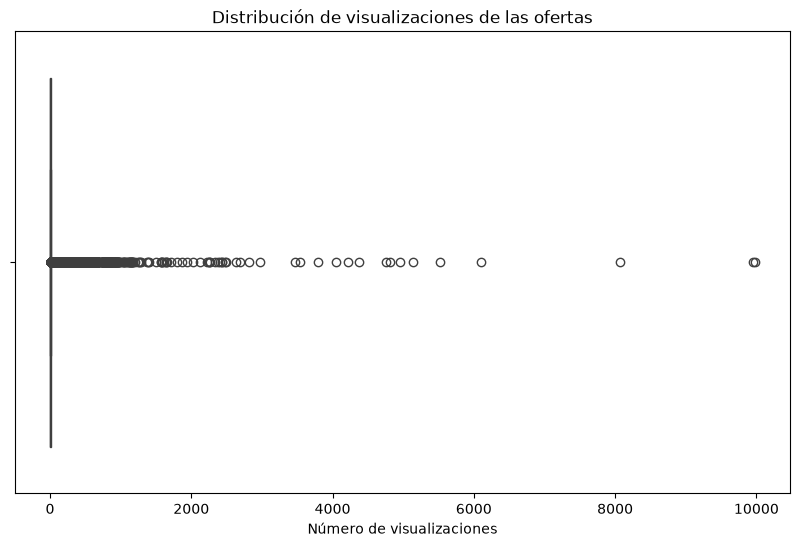

In [80]:
#BOXPLOT DE VIEWS
plt.figure(figsize=(10, 6))

sns.boxplot(x=postings["views"])
plt.title("Distribución de visualizaciones de las ofertas")
plt.xlabel("Número de visualizaciones")
plt.show()

La mayor parte de las ofertas tiene pocas visualizaciones y aparecen numerosos valores alejados de la distribución principal, llegando hasta casi 10.000 visualizaciones. Estos valores pueden considerarse posibles outliers, aunque no significa necesariamente que sean errores ya que algunas ofertas pueden haber tenido mucha más visibilidad que otras.

In [81]:
#DETECCIÓN DE OUTLIERS EN VIEWS MEDIANTE IQR

# 1. Calculamos el primer y tercer cuartil
Q1 = postings["views"].quantile(0.25)
Q3 = postings["views"].quantile(0.75)

# 2. Calculamos el rango intercuartílico
IQR = Q3 - Q1

# 3. Calculamos los límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Identificamos los posibles outliers
outliers_views = postings[
    (postings["views"] < limite_inferior) |
    (postings["views"] > limite_superior)
]

# 5. Calculamos el número y porcentaje de outliers
numero_outliers = len(outliers_views)
numero_validos = postings["views"].notna().sum()
porcentaje_outliers = numero_outliers / numero_validos * 100

# 6. Mostramos los resultados
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de posibles outliers: {numero_outliers:,}")
print(f"Porcentaje de posibles outliers: {porcentaje_outliers:.2f}%")

Q1: 3.00
Q3: 8.00
IQR: 5.00
Límite inferior: -4.50
Límite superior: 15.50
Número de posibles outliers: 16,902
Porcentaje de posibles outliers: 13.84%


Q1 = 3 → el 25 % de las ofertas tiene 3 visualizaciones o menos.

Q3 = 8 → el 75 % tiene 8 visualizaciones o menos.

IQR = 5.

El límite superior es 15,5.

Hay 16.902 posibles outliers, que representan el 13,84 % de las ofertas con views informado.
El límite inferior es -4,5, pero no nos preocupa porque views no puede ser negativo.

Lo más importante es que el método IQR considera outlier cualquier oferta con más de 15,5 visualizaciones. Esto hace que tengamos un porcentaje bastante elevado de posibles outliers.

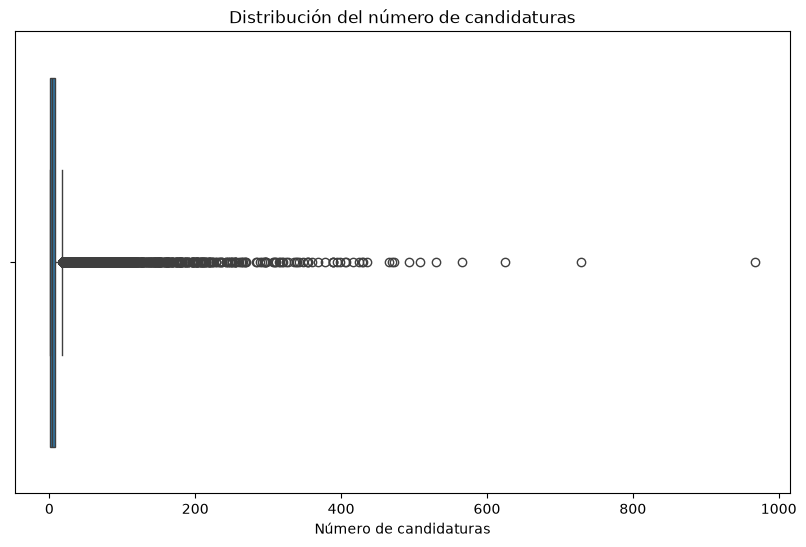

In [82]:
#BOXPLOT DE APPLIES
plt.figure(figsize=(10, 6))

sns.boxplot(x=postings["applies"])
plt.title("Distribución del número de candidaturas")
plt.xlabel("Número de candidaturas")
plt.show()

Hay una fuerte concentración de valores bajos y una cola muy larga hacia la derecha.Se observan muchos puntos alejados de la caja, llegando hasta aproximadamente 967 candidaturas. Esto indica que hay bastantes valores que estadísticamente podrían considerarse outliers.

In [83]:
#DETECCIÓN DE OUTLIERS EN APPLIES MEDIANTE IQR

# 1. Calculamos el primer y tercer cuartil
Q1 = postings["applies"].quantile(0.25)
Q3 = postings["applies"].quantile(0.75)

# 2. Calculamos el rango intercuartílico
IQR = Q3 - Q1

# 3. Calculamos los límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Identificamos los posibles outliers
outliers_applies = postings[
    (postings["applies"] < limite_inferior) |
    (postings["applies"] > limite_superior)
]

# 5. Calculamos el número y porcentaje de outliers
numero_outliers = len(outliers_applies)
numero_validos = postings["applies"].notna().sum()
porcentaje_outliers = numero_outliers / numero_validos * 100

# 6. Mostramos los resultados
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de posibles outliers: {numero_outliers:,}")
print(f"Porcentaje de posibles outliers: {porcentaje_outliers:.2f}%")

Q1: 1.00
Q3: 8.00
IQR: 7.00
Límite inferior: -9.50
Límite superior: 18.50
Número de posibles outliers: 2,897
Porcentaje de posibles outliers: 12.42%


Q1 = 1 → el 25 % de las ofertas tiene 1 candidatura o menos.

Q3 = 8 → el 75 % tiene 8 candidaturas o menos.

IQR = 7.

Límite superior = 18,5 
Las ofertas con más de 18,5 candidaturas se consideran posibles outliers según el método IQR.
Hay 2.897 posibles outliers.
Representan el 12,42 % de las ofertas que tienen información en applies.
El límite inferior es -9,5, pero no tiene relevancia porque no puede haber un número negativo de candidaturas

BOXPLOT DE SALARIES
Vamos a analizar los outliers salariales por pay_period.Para no mezclar salarios anuales, horarios, mensuales, etc vamos a unificarlos en salario anual utilizando el siguiente calculo

| `pay_period` | Conversión a salario anual |
| ------------ | -------------------------: |
| YEARLY       |                        × 1 |
| MONTHLY      |                       × 12 |
| WEEKLY       |                       × 52 |
| BIWEEKLY     |                       × 26 |
| HOURLY       |                    × 2.080 |


In [84]:
#NORMALIZACIÓN DE SALARIOS A ANUAL (creacion de las variables normalizadas)

factores = {
    "YEARLY": 1,
    "MONTHLY": 12,
    "WEEKLY": 52,
    "BIWEEKLY": 26,
    "HOURLY": 2080
}

salaries["annual_min_salary"] = (
    salaries["min_salary"] * salaries["pay_period"].map(factores)
)

salaries["annual_med_salary"] = (
    salaries["med_salary"] * salaries["pay_period"].map(factores)
)

salaries["annual_max_salary"] = (
    salaries["max_salary"] * salaries["pay_period"].map(factores)
)

In [85]:
#DETECCIÓN DE OUTLIERS SALARIALES MEDIANTE IQR

variables_salariales = [
    "annual_min_salary",
    "annual_med_salary",
    "annual_max_salary"
]

resultados_salarios = []

for variable in variables_salariales:
    
    # Eliminamos los valores nulos
    datos = salaries[variable].dropna()
    
    # Calculamos Q1 y Q3
    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    
    # Calculamos IQR
    IQR = Q3 - Q1
    
    # Calculamos los límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Identificamos los outliers
    outliers = datos[
        (datos < limite_inferior) |
        (datos > limite_superior)
    ]
    
    # Guardamos los resultados
    resultados_salarios.append({
        "variable": variable,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "outliers": len(outliers),
        "porcentaje_outliers": len(outliers) / len(datos) * 100
    })

resultados_salarios_df = pd.DataFrame(resultados_salarios)

resultados_salarios_df

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,outliers,porcentaje_outliers
0,annual_min_salary,50000.0,110000.0,60000.0,-40000.0,200000.0,755,2.224055
1,annual_med_salary,37440.0,72800.0,35360.0,-15600.0,125840.0,611,8.935361
2,annual_max_salary,66560.0,150980.0,84420.0,-60070.0,277610.0,1474,4.342063


Después de normalizar todos los salarios a valores anuales, se detectaron algunos valores extremos. La variable annual_med_salary presenta el mayor porcentaje de outliers (8,94%), seguida de annual_max_salary (4,34%) y annual_min_salary (2,22%). Estos valores no se eliminarán automáticamente, ya que pueden representar salarios reales de puestos con remuneraciones especialmente altas.

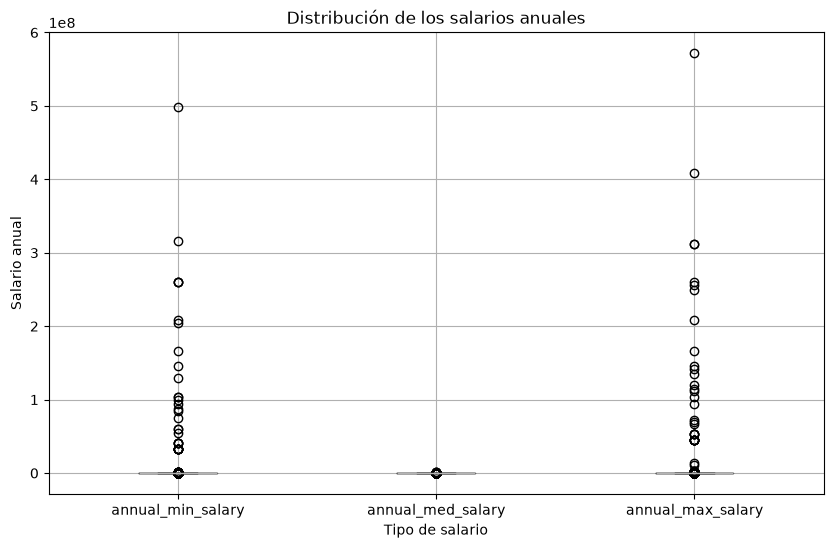

In [86]:
#BLOXPLOT SALARIES
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

salaries[
    [
        "annual_min_salary",
        "annual_med_salary",
        "annual_max_salary"
    ]
].boxplot()

plt.title("Distribución de los salarios anuales")
plt.ylabel("Salario anual")
plt.xlabel("Tipo de salario")

plt.show()

Los tres salarios presentan una distribución muy asimétrica hacia la derecha.

annual_min_salary: tiene varios valores extremos por encima de la distribución habitual.

annual_med_salary: también presenta outliers, aunque visualmente la escala hace que la caja quede muy comprimida.

annual_max_salary: es la variable que presenta los valores extremos más altos.

Hay valores que llegan aproximadamente a 500–575 millones de unidades monetarias anuales, que son claramente muy elevados respecto a la mayoría de los salarios.

In [87]:
#DETECCIÓN DE OUTLIERS EMPLOYEE_COUNT Y FOLLOWER_COUNT MEDIANTE IQR
variables = ["employee_count", "follower_count"]

for columna in variables:
    Q1 = employee_counts[columna].quantile(0.25)
    Q3 = employee_counts[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = employee_counts[
        (employee_counts[columna] < limite_inferior) |
        (employee_counts[columna] > limite_superior)
    ]

    print(f"\n--- {columna} ---")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")
    print(f"Porcentaje de outliers: {len(outliers) / len(employee_counts) * 100:.2f}%")


--- employee_count ---
Q1: 56.0
Q3: 2945.0
IQR: 2889.0
Límite inferior: -4277.5
Límite superior: 7278.5
Número de outliers: 5417
Porcentaje de outliers: 15.14%

--- follower_count ---
Q1: 2738.0
Q3: 74129.5
IQR: 71391.5
Límite inferior: -104349.25
Límite superior: 181216.75
Número de outliers: 5205
Porcentaje de outliers: 14.54%


employee_count: el 15,14% de los registros queda por encima de 7.278,5 empleados. Esto es razonable porque algunas empresas pueden ser muy grandes. El límite inferior es negativo, por lo que no genera outliers inferiores relevantes.

follower_count: el 14,54% supera los 181.216,75 seguidores. También puede ser perfectamente real para empresas grandes o muy conocidas.

En ambas variables hay una distribución muy asimétrica hacia la derecha, con una concentración de empresas relativamente pequeñas y un grupo de empresas con valores mucho mayores.

<Axes: >

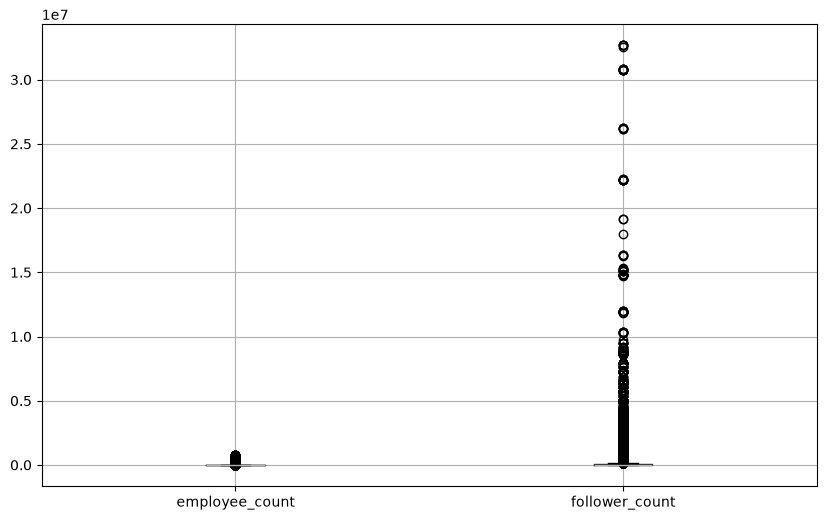

In [88]:
#BOXPLOT EMPLOYEE_COUNT Y FOLLOWER_COUNT
employee_counts[["employee_count", "follower_count"]].boxplot(
    figsize=(10, 6)
)

employee_count: la caja queda muy cerca de la parte inferior y aparecen numerosos puntos por encima. Esto indica una distribución muy asimétrica hacia la derecha, con muchas empresas relativamente pequeñas y algunas con un número de empleados mucho mayor.

follower_count: ocurre todavía de forma más marcada. Hay una gran concentración de valores bajos y numerosos valores extremos muy elevados.

No debemos interpretarlos automáticamente como errores: pueden corresponder a empresas grandes o con una gran cantidad de seguidores.

### 5. LIMPIEZA DE DATOS

### 5.1 corrección de tipos

En el punto 4.1 tipo de datos realicé la siguiente limpieza de tipos de datos:

timestamps → datetime

company_id → entero nullable

zip_code → string

fips → string

benefits.inferred → boolean

### 5.2 tratamiento de nulos

TABLA POSTINGS
| Variable                     | % nulos | Decisión                | Justificación                                                         |
| ---------------------------- | ------: | ----------------------- | --------------------------------------------------------------------- |
| `closed_time`                |  99,13% | **Mantener NaN**        | La ausencia puede indicar que la oferta no está cerrada               |
| `skills_desc`                |  98,03% | **Mantener por ahora**  | Demasiados nulos para imputar.| Variable                     | % nulos | Decisión                | Justificación                                                         |
| ---------------------------- | ------: | ----------------------- | --------------------------------------------------------------------- |
| `closed_time`                |  99,13% | **Mantener NaN**        | La ausencia puede indicar que la oferta no está cerrada               |
| `skills_desc`                |  98,03% | **Mantener por ahora**  | Analizar posteriormente como texto. Demasiados nulos para imputar |
| `med_salary`                 |  94,93% | **Mantener NaN**        | No podemos inventar un salario medio                                  |
| `remote_allowed`             |  87,69% | **Mantener NaN**        | NaN ≠ necesariamente "no remoto"                                      |
| `applies`                    |  81,17% | **Mantener NaN**        | No sabemos si 0 solicitudes o dato no registrado                      |
| `max_salary`                 |  75,94% | **Mantener NaN**        | No podemos imputar salarios arbitrariamente                           |
| `min_salary`                 |  75,94% | **Mantener NaN**        | Igual que `max_salary`                                                |
| `pay_period`                 |  70,87% | **Mantener NaN**        | Falta la periodicidad salarial                                        |
| `currency`                   |  70,87% | **Mantener NaN**        | No podemos asumir USD                                                 |
| `compensation_type`          |  70,87% | **Mantener NaN**        | Solo conocemos el tipo cuando está informado                          |
| `normalized_salary`          |  70,87% | **Mantener NaN**        | Es consecuencia de la falta de información salarial                   |
| `posting_domain`             |  32,27% | **Mantener NaN**        | No todas las ofertas tienen dominio registrado                        |
| `application_url`            |  29,60% | **Mantener NaN**        | No todas tienen URL de aplicación                                     |
| `formatted_experience_level` |  23,75% | **Categoría `Unknown`** | Es categórica y la ausencia puede tratarse como "no especificado"     |
| `fips`                       |  22,14% | **Mantener NaN**        | Código geográfico no disponible                                       |
| `zip_code`                   |  16,85% | **Mantener NaN**        | Código postal no disponible                                           |
| `company_name`               |   1,39% | **Mantener NaN**        | Son pocos casos y no debemos inventar nombres                         |
| `company_id`                 |   1,39% | **Mantener NaN**        | No podemos asignar una empresa desconocida                            |
| `views`                      |   1,36% | **Mantener NaN**        | No sabemos si significa 0 visualizaciones                             |
| `description`                |  0,006% | **Rellenar**            | Solo 7 registros; podemos indicar que no hay descripción              |
 |
| `med_salary`                 |  94,93% | **Mantener NaN**        | No podemos inventar un salario medio                                  |
| `remote_allowed`             |  87,69% | **Mantener NaN**        | NaN ≠ necesariamente "no remoto"                                      |
| `applies`                    |  81,17% | **Mantener NaN**        | No sabemos si 0 solicitudes o dato no registrado                      |
| `max_salary`                 |  75,94% | **Mantener NaN**        | No podemos imputar salarios arbitrariamente                           |
| `min_salary`                 |  75,94% | **Mantener NaN**        | Igual que `max_salary`                                                |
| `pay_period`                 |  70,87% | **Mantener NaN**        | Falta la periodicidad salarial                                        |
| `currency`                   |  70,87% | **Mantener NaN**        | No podemos asumir USD                                                 |
| `compensation_type`          |  70,87% | **Mantener NaN**        | Solo conocemos el tipo cuando está informado                          |
| `normalized_salary`          |  70,87% | **Mantener NaN**        | Es consecuencia de la falta de información salarial                   |
| `posting_domain`             |  32,27% | **Mantener NaN**        | No todas las ofertas tienen dominio registrado                        |
| `application_url`            |  29,60% | **Mantener NaN**        | No todas tienen URL de aplicación                                     |
| `formatted_experience_level` |  23,75% | **Categoría `Unknown`** | Es categórica y la ausencia puede tratarse como "no especificado"     |
| `fips`                       |  22,14% | **Mantener NaN**        | Código geográfico no disponible                                       |
| `zip_code`                   |  16,85% | **Mantener NaN**        | Código postal no disponible                                           |
| `company_name`               |   1,39% | **Mantener NaN**        | Son pocos casos y no debemos inventar nombres                         |
| `company_id`                 |   1,39% | **Mantener NaN**        | No podemos asignar una empresa desconocida                            |
| `views`                      |   1,36% | **Mantener NaN**        | No sabemos si significa 0 visualizaciones                             |
| `description`                |  0,006% | **Rellenar**            | Solo 7 registros; podemos indicar que no hay descripción              |


In [89]:
#formatted_experience_level: convertir los nulos en una categoría explícita
postings["formatted_experience_level"] = (
    postings["formatted_experience_level"].fillna("Unknown")
)

In [90]:
#description: como solamente hay 7 nulos, podemos rellenarlos
postings["description"] = (
    postings["description"].fillna("Sin descripción")
)

TABLA SALARIES

| Variable            | % nulos | Observación                             | Decisión       |
| ------------------- | ------: | --------------------------------------- | -------------- |
| `min_salary`        |  16,77% | Valores desde 1 hasta 85 millones       | Mantener nulos |
| `med_salary`        |  83,23% | Muy pocos datos y valores hasta 750.000 | Mantener nulos |
| `max_salary`        |  16,77% | Valores hasta 120 millones              | Mantener nulos |
| `annual_min_salary` |  16,77% | Valores hasta ~499 millones             | Mantener nulos |
| `annual_med_salary` |  83,23% | Valores hasta ~1,25 millones            | Mantener nulos |
| `annual_max_salary` |  16,77% | Valores hasta ~572 millones             | Mantener nulos |


In [91]:
#registros que tienen los salarios máximos
salaries[
    ["job_id", "min_salary", "med_salary", "max_salary",
     "pay_period", "currency",
     "annual_min_salary", "annual_med_salary", "annual_max_salary"]
].sort_values(
    "annual_max_salary", ascending=False
).head(20)

,job_id,min_salary,med_salary,max_salary,pay_period,currency,annual_min_salary,annual_med_salary,annual_max_salary
5109,3886471794,240000.0,NaN,275000.0,HOURLY,USD,499200000.0,NaN,572000000.0
23045,3904989090,151900.0,NaN,196570.0,HOURLY,USD,315952000.0,NaN,408865600.0
705,3887837646,125000.0,NaN,150000.0,HOURLY,USD,260000000.0,NaN,312000000.0
19189,3904407236,125000.0,NaN,150000.0,HOURLY,USD,260000000.0,NaN,312000000.0
29200,3901967159,125000.0,NaN,125000.0,HOURLY,USD,260000000.0,NaN,260000000.0
26280,3905282337,98467.0,NaN,123094.0,HOURLY,USD,204811360.0,NaN,256035520.0
38980,3902865442,100000.0,NaN,120000.0,HOURLY,USD,208000000.0,NaN,249600000.0
40635,3902879426,80000.0,NaN,100000.0,HOURLY,USD,166400000.0,NaN,208000000.0
6365,3888406456,70000.0,NaN,80000.0,HOURLY,USD,145600000.0,NaN,166400000.0
13384,3898176295,50000.0,NaN,70000.0,HOURLY,USD,104000000.0,NaN,145600000.0


Los valores nulos de las variables salariales no se imputan, ya que no existe información suficiente para determinar de forma fiable el salario correspondiente. Los valores extremos detectados en las variables salariales se mantienen temporalmente y los revisaré posteriormente

TABLA COMPANIES

| Variable       | % nulos | Observación                                                            | Decisión                                 |
| -------------- | ------: | ---------------------------------------------------------------------- | ---------------------------------------- |
| `company_size` |  11,33% | Categorías conocidas del 1 al 7                                        | Mantener nulos                           |
| `description`  |   1,21% | Pocos valores nulos; pueden sustituirse por `"Sin descripción"`        | Imputar                                  |
| `zip_code`     |   0,11% | Porcentaje de nulos muy reducido                                       | Mantener nulos                           |
| `address`      |   0,09% | Porcentaje de nulos muy reducido                                       | Mantener nulos                           |
| `state`        |   0,09% | Pocos nulos, pero existe inconsistencia entre `California`, `CA` y `0` | Mantener nulos + corregir inconsistencia |
| `city`         |  0,004% | Porcentaje de nulos prácticamente inexistente                          | Mantener nulos                           |
| `name`         |  0,004% | Porcentaje de nulos prácticamente inexistente                          | Mantener nulos                           |


In [92]:
#description: como son pocos nulos rellenarlo
companies["description"] = companies["description"].fillna("Sin descripción")

TABLA INDUSTRIES

| Variable        | % nulos | Observación                                                      | Decisión           |
| --------------- | ------: | ---------------------------------------------------------------- | ------------------ |
| `industry_id`   |      0% | Los identificadores están informados                             | Mantener           |
| `industry_name` |       — | 34 registros presentan `NaN`, pero tienen `industry_id` asociado | **Mantener nulos** |


In [93]:
industries[industries["industry_name"].isna()]

,industry_id,industry_name
160,431,NaN
168,564,NaN
171,616,NaN
243,1517,NaN
246,1600,NaN
247,1602,NaN
248,1633,NaN
249,1649,NaN
262,1759,NaN
271,1909,NaN


### 5.3 tratamiento de duplicados

En el punto 4.3 duplicados ya vi que no había valores duplicados

### 5.4 normalización de categorías

| Variable                     | Problema detectado                                           | Ejemplo                                                   | Decisión                                    |
| ---------------------------- | ------------------------------------------------------------ | --------------------------------------------------------- | ------------------------------------------- |
| `state`                      | Estados representados mediante nombre completo y abreviatura | `California` / `CA`, `New York` / `NY`, `Texas` / `TX`    | **Unificar categorías**                     |
| `state`                      | Valores no válidos                                           | `0`                                                       | **Revisar y tratar como valor desconocido** |
| `country`                    | Países codificados mediante códigos ISO de dos letras        | `US`, `GB`, `CA`, `IN`, etc.                              | **Mantener**                                |
| `country`                    | Valor no válido/desconocido                                  | `0`                                                       | **Revisar y tratar como valor desconocido** |
| `company_size`               | Categorías numéricas del 1 al 7                              | `1.0`–`7.0`                                               | **Mantener**                                |
| `formatted_work_type`        | Categorías normalizadas y legibles                           | `Full-time`, `Contract`, `Part-time`                      | **Mantener**                                |
| `work_type`                  | Categorías codificadas en mayúsculas y `_`                   | `FULL_TIME`, `PART_TIME`                                  | **Mantener**                                |
| `formatted_experience_level` | Categorías ya normalizadas                                   | `Entry level`, `Mid-Senior level`, `Director`             | **Mantener**                                |
| `application_type`           | Categorías diferenciadas correctamente                       | `OffsiteApply`, `ComplexOnsiteApply`, `SimpleOnsiteApply` | **Mantener**                                |
| `pay_period`                 | Categorías de periodicidad salarial                          | `YEARLY`, `MONTHLY`, `HOURLY`                             | **Mantener**                                |
| `currency`                   | Códigos monetarios estandarizados                            | `USD`, `EUR`, `CAD`, `GBP`                                | **Mantener**                                |
| `compensation_type`          | Una única categoría válida                                   | `BASE_SALARY`                                             | **Mantener**                                |
| `industry`                   | Categorías de industria ya diferenciadas                     | `Software Development`, `Financial Services`              | **Mantener**                                |
| `speciality`                 | Categorías textuales diferenciadas                           | `Recruiting`, `Staffing`, `Technology`                    | **Mantener**                                |
| `industry_name`              | 34 valores nulos, pero con `industry_id` informado           | `industry_id = 431` → `NaN`                               | **Mantener nulos**                          |
| `skill_abr`                  | Códigos abreviados estandarizados                            | `IT`, `SALE`, `MGMT`, `ENG`                               | **Mantener**                                |
| `skill_name`                 | Nombres completos asociados a los códigos                    | `Information Technology`, `Sales`, `Engineering`          | **Mantener**                                |


La variable state presenta una elevada heterogeneidad en sus categorías, con 789 valores diferentes. Se identifican inconsistencias derivadas del uso simultáneo de nombres completos y abreviaturas (California/CA), diferencias de formato y capitalización, errores ortográficos, valores correspondientes a ciudades o direcciones, códigos numéricos y categorías que representan múltiples ubicaciones. Por ello, se realiza una normalización de las categorías, unificando las distintas representaciones de una misma región y revisando los valores no válidos mediante la información disponible en city y country.

In [94]:
#UNIFICAR VARIABLE STATE: unificar los estados de EE. UU
state_mapping = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY"
}

companies["state"] = companies["state"].replace(state_mapping)

In [95]:
##UNIFICAR VARIABLE STATE: unificar variables evidentes
state_mapping_extra = {
    "WASHINGTON": "WA",
    "virginia": "VA",
    "mi": "MI",
    "Mn": "MN",
    "Ma": "MA",
    "Md": "MD",
    "sc": "SC",
    "Wi": "WI",
    "N.C.": "NC",
    "N.J.": "NJ",
    "N.D.": "ND",
    "D.C": "DC",
    "OHIO": "OH",
    "WI - Wisconsin": "WI",
    "MI - Michigan": "MI",
    "Minnesota (MN)": "MN",
    "Louisiana (LA)": "LA",
    "NEW JERSEY (NJ)": "NJ",
    "District of Columbia (D.C.)": "DC",
    "Illinos": "IL"
}

companies["state"] = companies["state"].replace(state_mapping_extra)

In [96]:
#UNIFICAR VARIABLE STATE: tratar los valores claramente incorrectos
companies["state"] = companies["state"].replace(0, np.nan)

In [97]:
#UNIFICAR VARIABLE STATE: seguir unificando variables evidentes
state_mapping = {
    "District of Columbia": "DC",
    "Texas (TX)": "TX",
    "NV - Nevada": "NV",
    "maryland": "MD",
    "Ga.": "GA",
    "CONNECTICUT": "CT",
    "Or": "OR",
    "NC": "NC",
    "New York": "NY",
    "Misssouri": "MO",
    "Al.": "AL",
    "N.W.": "NW"
}

companies["state"] = companies["state"].replace(state_mapping)

In [98]:
##UNIFICAR VARIABLE STATE: seguir unificando variables evidentes
state_mapping = {
    "District of Columbia": "DC",
    "Texas (TX)": "TX",
    "NV - Nevada": "NV",
    "maryland": "MD",
    "Ga.": "GA",
    "CONNECTICUT": "CT",
    "New York": "NY",
    "Misssouri": "MO",
    "Al.": "AL"
}

companies["state"] = companies["state"].replace(state_mapping)

In [99]:
#UNIFICAR VARIABLE STATE: convertir los 0 en nan
companies["state"] = companies["state"].replace("0", np.nan)

In [100]:
#RESULTADO LIMPIEZA VARIABLE STATE
companies["state"].value_counts(dropna=False).head(50)

state
CA         3148
NaN        2197
TX         1857
NY         1624
FL         1160
IL         1055
NJ          772
MA          752
PA          721
OH          681
VA          676
GA          654
NC          547
MI          544
CO          461
WA          444
MN          417
MD          406
WI          383
AZ          361
TN          353
MO          303
IN          297
DC          249
UT          213
CT          204
OR          196
SC          191
England     186
KS          149
AL          133
NV          121
LA          118
KY          112
NE          111
IA          111
OK          101
NH          100
Ontario      94
DE           87
AR           78
ID           62
RI           60
London       56
ME           52
HI           52
NM           50
MT           36
SD           32
Quebec       31
Name: count, dtype: int64

| Situación                        | Ejemplo                        | Tratamiento              |
| -------------------------------- | ------------------------------ | ------------------------ |
| Nombre completo y abreviatura    | `California` / `CA`            | Unificados               |
| Diferentes formatos              | `Texas (TX)` / `TX`            | Unificados               |
| Mayúsculas/minúsculas            | `maryland` / `MD`              | Unificados               |
| Abreviaturas con puntuación      | `Ga.` / `GA`                   | Unificados               |
| Valor desconocido                | `0`                            | Convertido a `NaN`       |
| Regiones internacionales válidas | `England`, `Ontario`, `Quebec` | Mantener                 |
| Ciudades válidas según país      | `London` → `GB`                | Mantener                 |
| Valores claramente incorrectos   | direcciones, códigos, `......` | Tratar como desconocidos |


In [101]:
#UNIFICAR VARIABLE COUNTRY
companies["country"].value_counts(dropna=False)

country
US    21635
0       727
GB      620
CA      258
IN      157
      ...  
JO        1
KY        1
VE        1
SC        1
TZ        1
Name: count, Length: 81, dtype: int64

In [102]:
#UNIFICAR VARIABLE COUNTRY
companies["country"].nunique(dropna=False)

81

In [103]:
#UNIFICAR VARIABLE COUNTRY
companies[companies["country"].isin(["0", "OO"])][["country", "state", "city"]].head(20)

,country,state,city
6,OO,NaN,Worldwide
52,0,NaN,0
335,0,MN,Minneapolis
538,OO,NaN,0
629,0,NaN,0
662,OO,NaN,0
767,0,NaN,0
814,0,NaN,0
912,OO,NaN,Worldwide
1170,OO,NaN,"International, global"


In [104]:
#UNIFICAR VARIABLE COUNTRY
companies["country"].dtype

dtype('O')

En country se identificaron 81 categorías diferentes. La mayoría corresponden a códigos de país de dos letras y presentan un formato homogéneo, por lo que se mantienen sin modificaciones. Se detectaron los valores 0 y OO, que no corresponden a códigos de país válidos. Estos valores aparecen asociados tanto a registros sin información geográfica como a registros que contienen información parcial en state o city. Para evitar realizar inferencias no justificadas, ambos valores se consideran categorías no válidas y se sustituyen por NaN. Los códigos de país válidos se mantienen en su formato original.

| Variable  | Observación                                                                                         | Ejemplos  | Decisión                                                    |
| --------- | --------------------------------------------------------------------------------------------------- | --------- | ----------------------------------------------------------- |
| `country` | La mayoría de categorías son códigos de país válidos de dos letras. Se detectan valores no válidos. | `0`, `OO` | **Mantener códigos válidos y convertir `0` y `OO` a `NaN`** |


In [105]:
#UNIFICAR VARIABLE COUNTRY: convertir lo 0 y 00 a nan
companies["country"] = companies["country"].replace([0, "0", "OO"], np.nan)

In [106]:
#RESULTADO LIMPIEZA VARIABLE COUNTRY
companies["country"].value_counts(dropna=False)

country
US     21635
NaN      744
GB       620
CA       258
IN       157
       ...  
JO         1
KY         1
VE         1
SC         1
TZ         1
Name: count, Length: 80, dtype: int64

In [107]:
# Traer el país de la empresa a la tabla de ofertas
postings = postings.merge(
    companies[["company_id", "country"]],
    on="company_id",
    how="left"
)

# Crear la columna region a partir del país
postings["region"] = postings["country"].apply(
    lambda x: "EEUU" if x == "US" else "Otros"
)

In [108]:
#Dataset que incluya solo las ofertas de EEUU, ya que el resto de mercado tienen un porcentaje minimo sobre el total
postings_eeuu = postings[postings["region"] == "EEUU"].copy()

In [109]:
total_ofertas = len(postings)
ofertas_eeuu = len(postings_eeuu)

eliminadas = total_ofertas - ofertas_eeuu
porcentaje_eliminadas = eliminadas / total_ofertas * 100

print("Ofertas totales:", total_ofertas)
print("Ofertas EEUU:", ofertas_eeuu)
print("Ofertas eliminadas:", eliminadas)
print("Porcentaje eliminado:", round(porcentaje_eliminadas, 2), "%")

Ofertas totales: 123849
Ofertas EEUU: 109995
Ofertas eliminadas: 13854
Porcentaje eliminado: 11.19 %


Del total de 123.849 ofertas de empleo, 116.791 corresponden al mercado estadounidense, lo que representa el 94,30 % del conjunto de datos. Al limitar el análisis a EEUU, se excluyen 7.058 ofertas (5,70 %), correspondientes principalmente a otras regiones geográficas.

### 5.5 tratamiento de texto

In [110]:
#TABLA COMPANIES
text_cols = ['name', 'description', 'state', 'country', 'city', 'zip_code', 'address', 'url']

for col in text_cols:
    print(f"\n--- {col} ---")
    print("Valores nulos:", companies[col].isna().sum())
    print("Cadenas vacías:", (companies[col].fillna("").str.strip() == "").sum())
    print("Ejemplos:")
    print(companies[col].dropna().head(5).tolist())


--- name ---
Valores nulos: 1
Cadenas vacías: 1
Ejemplos:
['IBM', 'GE HealthCare', 'Hewlett Packard Enterprise', 'Oracle', 'Accenture']

--- description ---
Valores nulos: 0
Cadenas vacías: 0
Ejemplos:
['At IBM, we do more than work. We create. We create as technologists, developers, and engineers. We create with our partners. We create with our competitors. If you\'re searching for ways to make the world work better through technology and infrastructure, software and consulting, then we want to work with you.\n\nWe\'re here to help every creator turn their "what if" into what is. Let\'s create something that will change everything.', 'Every day millions of people feel the impact of our intelligent devices, advanced analytics and artificial intelligence. As a leading global medical technology and digital solutions innovator, GE HealthCare enables clinicians to make faster, more informed decisions through intelligent devices, data analytics, applications and services, supported by its 

| Variable      | Valores nulos | Cadenas vacías* | Observación                                                                                    | Conclusión / Tratamiento                                                                  |
| ------------- | ------------: | --------------: | ---------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| `name`        |             1 |               1 | Se identifica un registro sin nombre de empresa.                                               | **Mantener como `NaN`**, ya que no se puede recuperar de forma fiable.                    |
| `description` |             0 |               0 | No presenta valores nulos ni cadenas vacías. El contenido contiene texto descriptivo completo. | **No realizar modificaciones** para conservar la información textual.                     |
| `state`       |         2.197 |           2.197 | Los valores vacíos corresponden a los `NaN` generados durante la limpieza anterior.            | **No modificar en 5.5**; ya fue tratado en la normalización de categorías (5.4).          |
| `country`     |           744 |             744 | Los valores vacíos corresponden a los `NaN` generados al sustituir `0` y `OO`.                 | **No modificar en 5.5**; ya fue tratado en 5.4.                                           |
| `city`        |             1 |               1 | Se identifica un registro sin ciudad. Los valores observados presentan texto válido.           | **Mantener como `NaN`** al no poder recuperar la información.                             |
| `zip_code`    |            28 |              28 | Se observan valores `0`, que no representan códigos postales válidos.                          | **Sustituir `0` por `NaN`**. Mantener como texto para conservar posibles ceros iniciales. |
| `address`     |            22 |              22 | Se observan valores como `-`, utilizados como ausencia de dirección.                           | **Sustituir `-` por `NaN`**.                                                              |
| `url`         |             0 |               0 | No presenta valores nulos ni cadenas vacías.                                                   | **No realizar modificaciones**.                                                           |


In [111]:
#LIMPIEZA TABLA COMPANIES

#Name
companies["name"] = companies["name"].replace(r"^\s*$", np.nan, regex=True)

#City
companies["city"] = companies["city"].replace(r"^\s*$", np.nan, regex=True)

#Zip code
companies["zip_code"] = companies["zip_code"].replace(["0", 0], np.nan)

#Address
companies["address"] = companies["address"].replace(r"^\s*-\s*$", np.nan, regex=True)

In [112]:
tables = {
    "industries": industries,
    "company_industries": company_industries,
    "company_specialities": company_specialities,
    "benefits": benefits,
    "job_skills": job_skills,
    "skills": skills,
    "salaries": salaries,
    "job_industries": job_industries,
    "employee_counts":employee_counts,
    "postings":postings
}

for name, df in tables.items():
    print(f"\n===== {name} =====")
    print(df.select_dtypes(include="object").columns.tolist())


===== industries =====
['industry_name']

===== company_industries =====
['industry']

===== company_specialities =====
['speciality']

===== benefits =====
['type']

===== job_skills =====
['skill_abr']

===== skills =====
['skill_abr', 'skill_name']

===== salaries =====
['pay_period', 'currency', 'compensation_type']

===== job_industries =====
[]

===== employee_counts =====
[]

===== postings =====
['company_name', 'title', 'description', 'pay_period', 'location', 'formatted_work_type', 'job_posting_url', 'application_url', 'application_type', 'formatted_experience_level', 'skills_desc', 'posting_domain', 'work_type', 'currency', 'compensation_type', 'country', 'region']


In [113]:
text_tables = {
    "industries": industries,
    "company_industries": company_industries,
    "company_specialities": company_specialities,
    "benefits": benefits,
    "job_skills": job_skills,
    "skills": skills,
    "postings": postings
}

for name, df in text_tables.items():
    print(f"\n========== {name.upper()} ==========")

    text_cols = df.select_dtypes(include="object").columns

    for col in text_cols:
        nulos = df[col].isna().sum()
        vacios = (df[col].fillna("").str.strip() == "").sum()

        print(f"{col}: Nulos = {nulos} | Cadenas vacías = {vacios}")


========== INDUSTRIES ==========
industry_name: Nulos = 34 | Cadenas vacías = 34

========== COMPANY_INDUSTRIES ==========
industry: Nulos = 0 | Cadenas vacías = 0

========== COMPANY_SPECIALITIES ==========
speciality: Nulos = 0 | Cadenas vacías = 0

========== BENEFITS ==========
type: Nulos = 0 | Cadenas vacías = 0

========== JOB_SKILLS ==========
skill_abr: Nulos = 0 | Cadenas vacías = 0

========== SKILLS ==========
skill_abr: Nulos = 0 | Cadenas vacías = 0
skill_name: Nulos = 0 | Cadenas vacías = 0

========== POSTINGS ==========
company_name: Nulos = 1719 | Cadenas vacías = 1719
title: Nulos = 0 | Cadenas vacías = 0
description: Nulos = 0 | Cadenas vacías = 0
pay_period: Nulos = 87776 | Cadenas vacías = 87776
location: Nulos = 0 | Cadenas vacías = 0
formatted_work_type: Nulos = 0 | Cadenas vacías = 0
job_posting_url: Nulos = 0 | Cadenas vacías = 0
application_url: Nulos = 36665 | Cadenas vacías = 36665
application_type: Nulos = 0 | Cadenas vacías = 0
formatted_experience_level

| Tabla                  | Variable                     | Problema detectado                                | Decisión                                                    |
| ---------------------- | ---------------------------- | ------------------------------------------------- | ----------------------------------------------------------- |
| `industries`           | `industry_name`              | 34 valores nulos                                  | Mantener `NaN`; no se pueden recuperar de forma fiable      |
| `company_industries`   | `industry`                   | Sin valores vacíos                                | Mantener                                                    |
| `company_specialities` | `speciality`                 | Sin valores vacíos                                | Mantener                                                    |
| `benefits`             | `type`                       | Sin valores vacíos                                | Mantener                                                    |
| `job_skills`           | `skill_abr`                  | Sin valores vacíos                                | Mantener                                                    |
| `skills`               | `skill_abr`                  | Sin valores vacíos                                | Mantener                                                    |
| `skills`               | `skill_name`                 | Sin valores vacíos                                | Mantener                                                    |
| `postings`             | `company_name`               | 1.719 valores nulos                               | Mantener `NaN`; no imputar sin información fiable           |
| `postings`             | `title`                      | Algunos espacios al inicio/final                  | Eliminar espacios sobrantes con `.str.strip()`              |
| `postings`             | `description`                | Texto libre, sin nulos                            | Mantener el contenido original; no modificar semánticamente |
| `postings`             | `location`                   | Texto con distintas representaciones de ubicación | Mantener; su normalización se puede tratar aparte           |
| `postings`             | `job_posting_url`            | Sin valores nulos                                 | Mantener                                                    |
| `postings`             | `application_url`            | 36.665 valores nulos                              | Mantener `NaN`; no imputar                                  |
| `postings`             | `formatted_experience_level` | Sin valores nulos                                 | Mantener; ya normalizado en 5.4                             |
| `postings`             | `skills_desc`                | 121.410 valores nulos                             | Mantener `NaN`; no inventar información                     |
| `postings`             | `posting_domain`             | 39.968 valores nulos                              | Mantener `NaN`; no imputar                                  |


In [114]:
#LIMPIAR VARIABLES COMPANY_NAME Y TITLE
for col in ["company_name", "title"]:
    postings[col] = postings[col].str.strip()

### 5.6 tratamiento de salarios

In [115]:
print(salaries.info())

print("\n--- Valores nulos ---")
print(salaries.isna().sum())

print("\n--- Estadísticos numéricos ---")
print(salaries.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40785 entries, 0 to 40784
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   salary_id          40785 non-null  int64  
 1   job_id             40785 non-null  int64  
 2   max_salary         33947 non-null  float64
 3   med_salary         6838 non-null   float64
 4   min_salary         33947 non-null  float64
 5   pay_period         40785 non-null  object 
 6   currency           40785 non-null  object 
 7   compensation_type  40785 non-null  object 
 8   annual_min_salary  33947 non-null  float64
 9   annual_med_salary  6838 non-null   float64
 10  annual_max_salary  33947 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 3.4+ MB
None

--- Valores nulos ---
salary_id                0
job_id                   0
max_salary            6838
med_salary           33947
min_salary            6838
pay_period               0
currency       

In [116]:
print(salaries.columns.tolist())

['salary_id', 'job_id', 'max_salary', 'med_salary', 'min_salary', 'pay_period', 'currency', 'compensation_type', 'annual_min_salary', 'annual_med_salary', 'annual_max_salary']


In [117]:
#DETECTAR VALORES SOSPECHOSOS
print("=== annual_min_salary > 1.000.000 ===")
print(
    salaries[salaries["annual_min_salary"] > 1_000_000][
        ["job_id", "min_salary", "max_salary", "pay_period",
         "currency", "annual_min_salary", "annual_max_salary"]
    ]
)

print("\n=== annual_max_salary > 1.000.000 ===")
print(
    salaries[salaries["annual_max_salary"] > 1_000_000][
        ["job_id", "min_salary", "max_salary", "pay_period",
         "currency", "annual_min_salary", "annual_max_salary"]
    ]
)

=== annual_min_salary > 1.000.000 ===
           job_id  min_salary   max_salary pay_period currency  \
705    3887837646    125000.0     150000.0     HOURLY      USD   
4837   3889117757     45000.0      50000.0     HOURLY      USD   
5109   3886471794    240000.0     275000.0     HOURLY      USD   
5483   3889124037     42000.0      45000.0     HOURLY      USD   
6365   3888406456     70000.0      80000.0     HOURLY      USD   
13384  3898176295     50000.0      70000.0     HOURLY      USD   
14339  3901667956     50000.0      65000.0     HOURLY      USD   
14970  3901169389     90000.0     110000.0    MONTHLY      USD   
17733  3904387609     54009.0      66976.0   BIWEEKLY      USD   
18104  3904388204     71323.0      89965.0   BIWEEKLY      USD   
18440  3904392687     36000.0      54000.0     HOURLY      USD   
19189  3904407236    125000.0     150000.0     HOURLY      USD   
19401  3904388630     62000.0      68000.0     HOURLY      USD   
20342  3904911743  85000000.0  1200000

In [118]:
#LOCALIZAR VALORES A 0
print("=== Salarios iguales a 0 ===")

print(
    salaries[
        (salaries["min_salary"] == 0) |
        (salaries["med_salary"] == 0) |
        (salaries["max_salary"] == 0)
    ][
        ["job_id", "min_salary", "med_salary", "max_salary",
         "pay_period", "currency",
         "annual_min_salary", "annual_med_salary", "annual_max_salary"]
    ]
)

=== Salarios iguales a 0 ===
           job_id  min_salary  med_salary  max_salary pay_period currency  \
3201   3885869218         NaN         0.0         NaN     YEARLY      USD   
3993   3885114173         NaN         0.0         NaN     YEARLY      USD   
9177   3891076695         NaN         0.0         NaN     YEARLY      USD   
12736  3888041858         NaN         0.0         NaN     YEARLY      USD   
14306  3898168102         NaN         0.0         NaN     YEARLY      USD   
19444  3900978299         NaN         0.0         NaN     YEARLY      USD   
21040  3903447133         NaN         0.0         NaN     YEARLY      USD   
21319  3904926733         NaN         0.0         NaN     YEARLY      USD   
30611  3901982077         NaN         0.0         NaN     YEARLY      USD   
32763  3902306070         NaN         0.0         NaN     YEARLY      USD   
32765  3902302199         NaN         0.0         NaN     YEARLY      USD   
32769  3902301244         NaN         0.0      

Un salario medio de 0 representa  ausencia de salario, no un salario real. Por tanto, lo correcto es convertir esos 0 a NaN.

In [119]:
salaries["med_salary"] = salaries["med_salary"].replace(0, np.nan)
salaries["annual_med_salary"] = salaries["annual_med_salary"].replace(0, np.nan)

In [120]:
sospechosos = salaries[
    (salaries["annual_min_salary"] > 1_000_000) |
    (salaries["annual_max_salary"] > 1_000_000)
]

print(sospechosos[
    ["job_id", "min_salary", "max_salary", "pay_period",
     "currency", "annual_min_salary", "annual_max_salary"]
].to_string(index=False))

    job_id  min_salary  max_salary pay_period currency  annual_min_salary  annual_max_salary
3884920734    350000.0   1500000.0     YEARLY      USD           350000.0          1500000.0
3884923184    350000.0   1500000.0     YEARLY      USD           350000.0          1500000.0
3884929144    350000.0   1500000.0     YEARLY      USD           350000.0          1500000.0
3884921825    350000.0   1500000.0     YEARLY      USD           350000.0          1500000.0
3887837646    125000.0    150000.0     HOURLY      USD        260000000.0        312000000.0
3884923252    350000.0   1500000.0     YEARLY      USD           350000.0          1500000.0
3884925602    350000.0   1500000.0     YEARLY      USD           350000.0          1500000.0
3884928788    350000.0   1500000.0     YEARLY      USD           350000.0          1500000.0
3884931731    350000.0   1500000.0     YEARLY      USD           350000.0          1500000.0
3884923962    350000.0   1500000.0     YEARLY      USD           35000

In [121]:
print(
    salaries[salaries["annual_max_salary"] > 1_000_000]
    .groupby("pay_period")["annual_max_salary"]
    .agg(["count", "min", "max", "median"])
)

            count         min          max      median
pay_period                                            
BIWEEKLY        6   1741376.0    2339090.0   2117609.0
HOURLY         33  10524800.0  572000000.0  72467200.0
MONTHLY         2   1200000.0    1320000.0   1260000.0
YEARLY         24   1000001.0  120000000.0   1500000.0


Hay 65 registros con un salario anual superior a 1.000.000, pero están repartidos entre distintos períodos (HOURLY:33, YEARLY:24,BIWEEKLY: 6, MONTHLY:2)
El problema parece estar principalmente en la conversión a salario anual de algunos valores que probablemente tienen una unidad (pay_period) incorrecta o que contienen importes atípicos

In [122]:
salaries["annual_min_salary_original"] = salaries["annual_min_salary"]
salaries["annual_med_salary_original"] = salaries["annual_med_salary"]
salaries["annual_max_salary_original"] = salaries["annual_max_salary"]

In [123]:
periodos_sospechosos = ["HOURLY", "BIWEEKLY", "MONTHLY"]

mask = (
    salaries["pay_period"].isin(periodos_sospechosos)
    & (
        (salaries["annual_min_salary"] > 1_000_000) |
        (salaries["annual_med_salary"] > 1_000_000) |
        (salaries["annual_max_salary"] > 1_000_000)
    )
)

salaries.loc[mask, [
    "annual_min_salary",
    "annual_med_salary",
    "annual_max_salary"
]] = np.nan

In [124]:
#LIMPIEZA SALARIOS ELEVADOS
periodos_sospechosos = ["HOURLY", "BIWEEKLY", "MONTHLY"]

mask = (
    salaries["pay_period"].isin(periodos_sospechosos)
    & (
        (salaries["annual_min_salary"] > 1_000_000) |
        (salaries["annual_med_salary"] > 1_000_000) |
        (salaries["annual_max_salary"] > 1_000_000)
    )
)

salaries.loc[mask, [
    "annual_min_salary",
    "annual_med_salary",
    "annual_max_salary"
]] = np.nan

Se revisaron las variables salariales originales y las variables anualizadas. Se detectaron 16 registros con salario medio igual a cero, que fueron considerados valores no válidos y transformados a NaN. Además, se identificaron 42 registros con salarios anualizados superiores a 1.000.000 USD procedentes de períodos HOURLY, BIWEEKLY o MONTHLY, cuyos valores resultaban inconsistentes con la unidad de pago y fueron tratados como valores no plausibles en las variables anualizadas. Los salarios anuales elevados registrados directamente como YEARLY se conservaron al no existir evidencia suficiente para considerarlos errores.

### 5.7 outliers

| Variable             | ¿Detectar outliers? | Tratamiento de los outliers                                            |
| -------------------- | ------------------- | ---------------------------------------------------------------------- |
| `views`              | ✅ Sí                | Se conservan, no se realizan modificaciones                            |
| `applies`            | ✅ Sí                | Se conservan, no se realizan modificaciones                            |
| `employee_count`     | ✅ Sí                | Se conservan, no se realizan modificaciones                            |
| `follower_count`     | ✅ Sí                | Se conservan, no se realizan modificaciones                            |
| Variables salariales | ✅ Sí                | **Se detectan, pero se conservan sin modificaciones ni eliminaciones** |


En el análisis de outliers del punto 4.7 se identificaron valores extremos en las principales variables numéricas mediante el método IQR. Sin embargo, tras analizar el contexto de los datos, se decide no eliminar ni modificar los valores atípicos de "views", "applies", "employee_count", "follower_count" ni de las variables salariales. Estos valores pueden representar situaciones reales, como ofertas con una elevada popularidad, empresas de gran tamaño o salarios elevados.

Por tanto, la limpieza de outliers se centró en su detección y análisis, conservando los valores originales al no existir evidencia suficiente de que fueran errores. De esta forma, se evita perder información potencialmente válida y se mantiene la integridad del conjunto de datos para el análisis posterior.


### 6. ANALISIS POR TIPO VARIABLE

### 6.1 Variables de texto

Las variables que interesan tratar como texto son principalmente title, description y skills_desc.

En el punto 5.5 title se normalizó eliminando espacios sobrantes, description se mantiene sin modificar semánticamente y skills_desc conserva sus nulos porque no se puede inventar información.

In [125]:
#Longitud de las variables de texto

postings["title_length"] = postings["title"].str.len()
postings["description_length"] = postings["description"].str.len()
postings["skills_desc_length"] = postings["skills_desc"].str.len()

postings[[
    "title_length",
    "description_length",
    "skills_desc_length"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
title_length,123849.0,31.509362,16.202705,2.0,20.0,28.0,39.0,200.0
description_length,123849.0,3766.252170,2146.617180,2.0,2176.0,3435.0,4986.0,23201.0
skills_desc_length,2439.0,204.898729,545.914274,3.0,33.0,33.0,103.0,3602.0


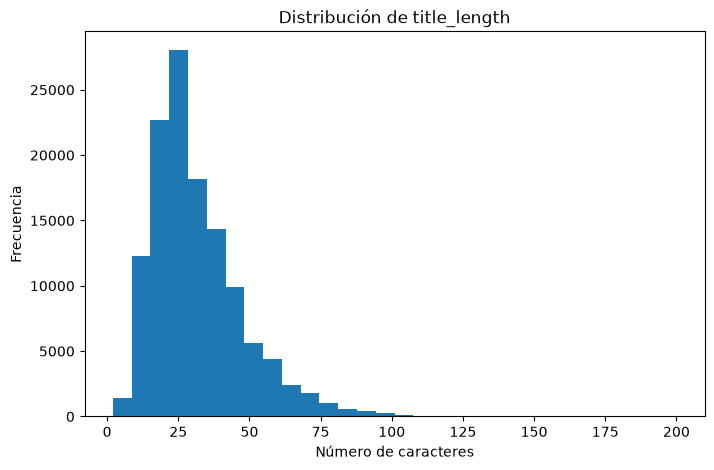

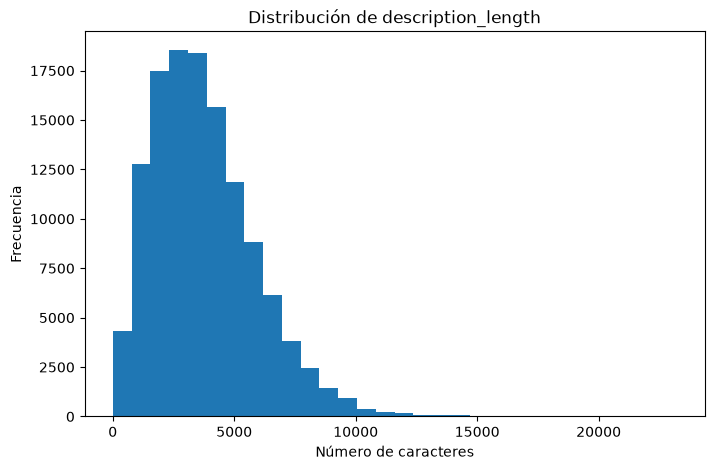

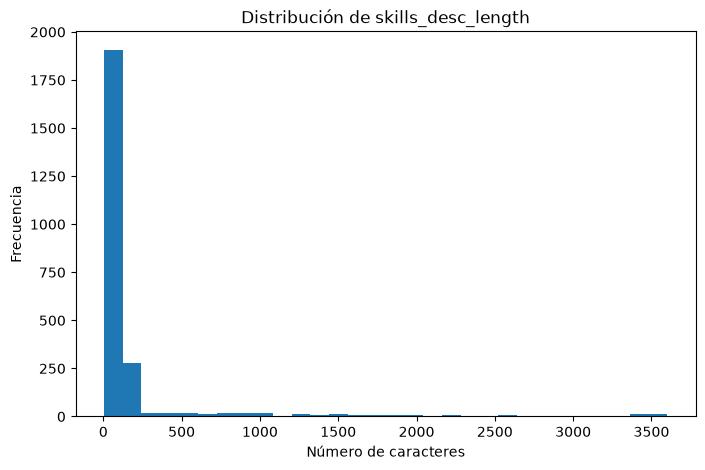

In [126]:
#representacion grafica longitud de las variables texto
variables_texto = [
    "title_length",
    "description_length",
    "skills_desc_length"
]

for variable in variables_texto:
    plt.figure(figsize=(8, 5))
    plt.hist(postings[variable].dropna(), bins=30)
    plt.title(f"Distribución de {variable}")
    plt.xlabel("Número de caracteres")
    plt.ylabel("Frecuencia")
    plt.show()

VARIABLE TITLE

In [127]:
#titulos mas frecuentes
top_titulos = postings["title"].value_counts().head(20)

top_titulos

title
Sales Manager                      673
Customer Service Representative    375
Project Manager                    359
Administrative Assistant           259
Senior Accountant                  243
Executive Assistant                228
Salesperson                        211
Registered Nurse                   210
Receptionist                       204
Staff Accountant                   203
Account Executive                  196
Retail Sales Associate             190
Sales Associate                    189
Software Engineer                  182
Controller                         178
Account Manager                    173
Store Manager                      166
Senior Software Engineer           162
ASSISTANT STORE MANAGER            161
Assistant Manager                  161
Name: count, dtype: int64

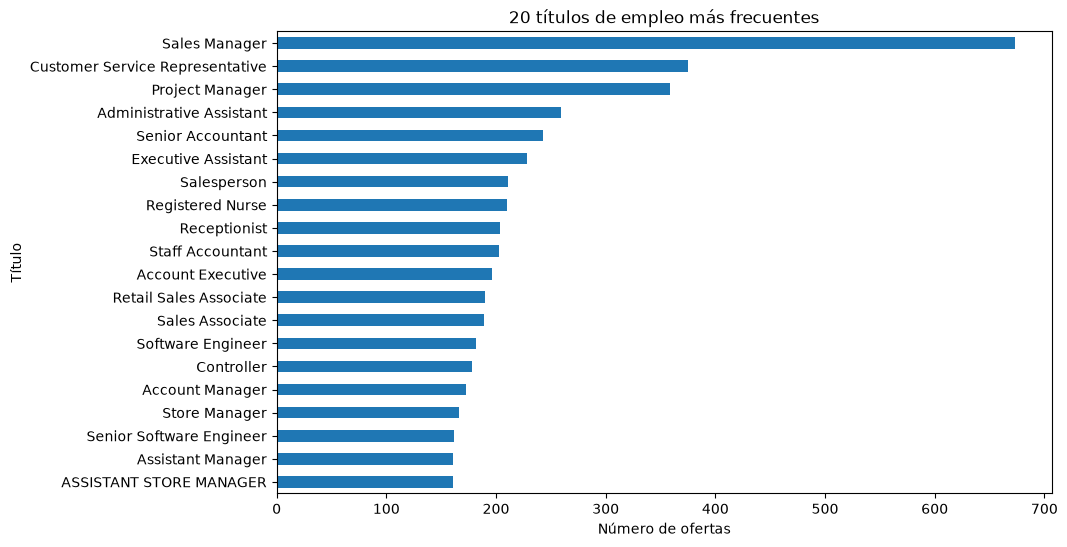

In [128]:
#representacion grafica titulos mas frecuentes
plt.figure(figsize=(10, 6))

top_titulos.sort_values().plot(kind="barh")

plt.title("20 títulos de empleo más frecuentes")
plt.xlabel("Número de ofertas")
plt.ylabel("Título")
plt.show()

In [129]:
#palabras mas comunes en los titulos
from collections import Counter

texto_titulos = " ".join(
    postings["title"].dropna().astype(str).str.lower()
)

palabras_titulos = texto_titulos.split()

frecuencia_palabras = Counter(palabras_titulos)

frecuencia_palabras.most_common(30)

[('-', 31473),
 ('manager', 15645),
 ('engineer', 9135),
 ('sales', 8103),
 ('senior', 7932),
 ('assistant', 6467),
 ('specialist', 6220),
 ('associate', 6027),
 ('technician', 4989),
 ('nurse', 4812),
 ('analyst', 4409),
 ('and', 3874),
 ('service', 3611),
 ('&', 3525),
 ('time', 3249),
 ('project', 3229),
 ('lead', 2958),
 ('director', 2928),
 ('registered', 2883),
 ('representative', 2848),
 ('business', 2763),
 ('of', 2688),
 ('coordinator', 2559),
 ('operations', 2505),
 ('developer', 2422),
 ('data', 2319),
 ('account', 2296),
 ('customer', 2246),
 ('rn', 2211),
 ('manager,', 2120)]

In [130]:
#eliminar palabras comunes en ingles en los titulos
stopwords = {
    "of", "and", "the", "for", "a", "to", "in",
    "with", "on", "at", "an", "as", "is", "by","&"
}

palabras_filtradas = [
    palabra for palabra in palabras_titulos
    if palabra not in stopwords
]

frecuencia_titulos = Counter(palabras_filtradas)

frecuencia_titulos.most_common(30)

[('-', 31473),
 ('manager', 15645),
 ('engineer', 9135),
 ('sales', 8103),
 ('senior', 7932),
 ('assistant', 6467),
 ('specialist', 6220),
 ('associate', 6027),
 ('technician', 4989),
 ('nurse', 4812),
 ('analyst', 4409),
 ('service', 3611),
 ('time', 3249),
 ('project', 3229),
 ('lead', 2958),
 ('director', 2928),
 ('registered', 2883),
 ('representative', 2848),
 ('business', 2763),
 ('coordinator', 2559),
 ('operations', 2505),
 ('developer', 2422),
 ('data', 2319),
 ('account', 2296),
 ('customer', 2246),
 ('rn', 2211),
 ('manager,', 2120),
 ('development', 2108),
 ('support', 2055),
 ('care', 2008)]

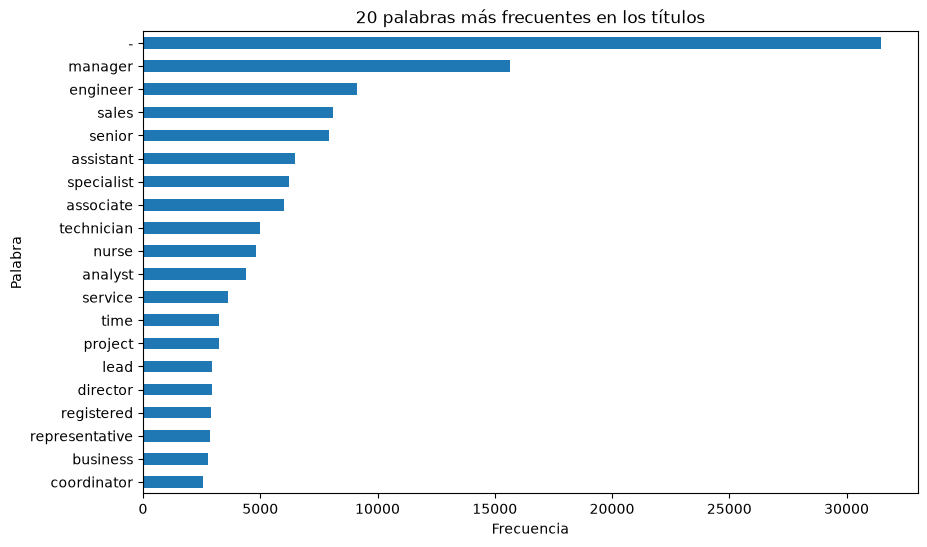

In [131]:
#representacion grafica palabras mas comunes en los titulos
top_palabras = pd.Series(
    dict(frecuencia_titulos.most_common(20))
)

plt.figure(figsize=(10, 6))

top_palabras.sort_values().plot(kind="barh")

plt.title("20 palabras más frecuentes en los títulos")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.show()

manager (15.645): es el término más frecuente.

engineer (9.135), sales (8.103) y senior (7.932): muestran una presencia importante de puestos de ingeniería, ventas y posiciones de nivel senior.

assistant, specialist, associate y technician  representando distintos tipos de roles profesionales.

nurse, analyst, developer, data y project muestran la presencia de perfiles sanitarios, analíticos, tecnológicos y relacionados con proyectos.

director, lead, coordinator y operations, asociados a puestos de responsabilidad y gestión.

VARIABLE DESCRIPTION

In [132]:
postings["description"].dropna().head(5)

0    Job descriptionA leading real estate firm in N...
1    At Aspen Therapy and Wellness , we are committ...
2    The National Exemplar is accepting application...
3    Senior Associate Attorney - Elder Law / Trusts...
4    Looking for HVAC service tech with experience ...
Name: description, dtype: object

In [133]:
#palabras mas frecuentes de la variable description
texto_descripciones = " ".join(
    postings["description"].dropna().astype(str).str.lower()
)

palabras_descripciones = texto_descripciones.split()

frecuencia_descripciones = Counter(palabras_descripciones)

frecuencia_descripciones.most_common(30)

[('and', 3742647),
 ('to', 2036453),
 ('the', 1798665),
 ('of', 1472811),
 ('a', 1104793),
 ('in', 1040110),
 ('with', 854759),
 ('for', 799507),
 ('or', 554442),
 ('is', 498353),
 ('our', 467911),
 ('as', 450189),
 ('we', 359245),
 ('on', 342750),
 ('are', 334240),
 ('be', 329276),
 ('you', 318053),
 ('work', 301176),
 ('an', 294788),
 ('will', 274828),
 ('experience', 267780),
 ('all', 263729),
 ('that', 258207),
 ('this', 238583),
 ('at', 224214),
 ('by', 222397),
 ('your', 203436),
 ('other', 189701),
 ('team', 188947),
 ('including', 154514)]

In [134]:
#eliminar palabras mas frecuentes en ingles de la variable description
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter

# Unir todas las descripciones
texto_descripciones = " ".join(
    postings["description"].dropna().astype(str).str.lower()
)

# Separar en palabras
palabras_descripciones = texto_descripciones.split()

# Eliminar stopwords
palabras_filtradas = [
    palabra for palabra in palabras_descripciones
    if palabra not in ENGLISH_STOP_WORDS
]

# Contar frecuencias
frecuencia_descripciones = Counter(palabras_filtradas)

# Mostrar las 30 palabras más frecuentes
frecuencia_descripciones.most_common(30)

[('work', 301176),
 ('experience', 267780),
 ('team', 188947),
 ('including', 154514),
 ('job', 149935),
 ('business', 147151),
 ('ability', 139249),
 ('customer', 131862),
 ('support', 123559),
 ('management', 117330),
 ('company', 113658),
 ('position', 113156),
 ('&', 110836),
 ('-', 107962),
 ('skills', 107502),
 ('years', 106633),
 ('new', 104282),
 ('sales', 104076),
 ('required', 103296),
 ('care', 99351),
 ('opportunity', 98049),
 ('working', 97927),
 ('service', 97029),
 ('health', 95510),
 ('time', 92834),
 ('data', 91903),
 ('benefits', 91625),
 ('provide', 90866),
 ('ensure', 86168),
 ('information', 84969)]

In [135]:
#segundo filtrado de eliminacion de palabras comunes en la variable description
stopwords_extra = {
    "work", "working", "job", "position", "opportunity",
    "company", "business", "including", "provide", "ensure",
    "&", "-"
}

palabras_filtradas_2 = [
    palabra for palabra in palabras_filtradas
    if palabra not in stopwords_extra
]

frecuencia_descripciones_2 = Counter(palabras_filtradas_2)

frecuencia_descripciones_2.most_common(30)

[('experience', 267780),
 ('team', 188947),
 ('ability', 139249),
 ('customer', 131862),
 ('support', 123559),
 ('management', 117330),
 ('skills', 107502),
 ('years', 106633),
 ('new', 104282),
 ('sales', 104076),
 ('required', 103296),
 ('care', 99351),
 ('service', 97029),
 ('health', 95510),
 ('time', 92834),
 ('data', 91903),
 ('benefits', 91625),
 ('information', 84969),
 ('related', 82111),
 ('knowledge', 81614),
 ('role', 81472),
 ('employment', 81147),
 ('development', 79800),
 ('and/or', 78791),
 ('project', 75300),
 ('services', 74006),
 ('equal', 71011),
 ('communication', 69853),
 ('employees', 68296),
 ('medical', 66691)]

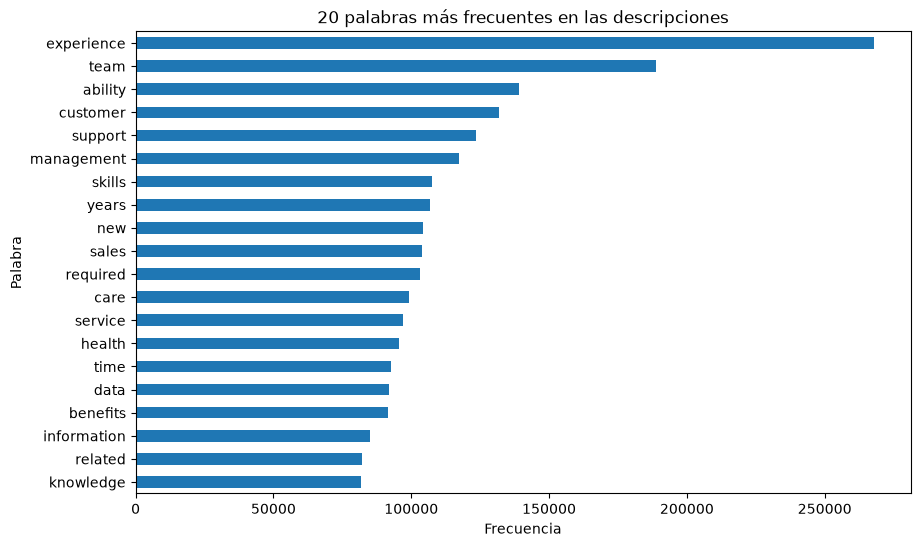

In [136]:
#representacion grafica palabras mas comunes en description
top_palabras = pd.Series(
    dict(frecuencia_descripciones_2.most_common(20))
)

plt.figure(figsize=(10, 6))

top_palabras.sort_values().plot(kind="barh")

plt.title("20 palabras más frecuentes en las descripciones")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.show()

experience, years, skills, knowledge y required → indican que la experiencia y las competencias requeridas tienen mucho peso en las ofertas.

team, communication, management → reflejan la importancia de las capacidades de trabajo en equipo y gestión.

customer, sales, service, support → muestran una presencia importante de puestos relacionados con clientes, ventas y servicios.

health, care, medical → indican una presencia destacable del sector sanitario.

data, development, project → aparecen términos relacionados con datos, desarrollo y gestión de proyectos.


VARIABLE SKILLS_DESC

In [137]:
postings["skills_desc"].notna().value_counts(normalize=True) * 100

skills_desc
False    98.030666
True      1.969334
Name: proportion, dtype: float64

La variable tiene una cantidad muy elevada de valores ausentes (98%) por lo que no se puede tener en cuenta para incluiarla en un analisis

### 6.2 Skills

In [138]:
#habilidades mas asociadas a ofertas
job_skills["skill_abr"].value_counts().head(20)

skill_abr
IT      26137
SALE    22475
MGMT    20861
MNFC    18185
HCPR    17369
BD      14290
ENG     13009
OTHR    12608
FIN      8540
MRKT     5525
ACCT     5461
ADM      4860
CUST     4292
PRJM     3997
ANLS     3858
RSCH     2986
HR       2647
LGL      2371
CNSL     2338
EDU      2290
Name: count, dtype: int64

In [139]:
skills.head()

,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution


In [140]:
skills_frecuencia = (
    job_skills
    .merge(skills, on="skill_abr", how="left")
)

skills_frecuencia.head()

,job_id,skill_abr,skill_name
0,3884428798,MRKT,Marketing
1,3884428798,PR,Public Relations
2,3884428798,WRT,Writing/Editing
3,3887473071,SALE,Sales
4,3887465684,FIN,Finance


In [141]:
#habilidades mas asociadas a ofertas incluyendo el nombre
top_skills = (
    skills_frecuencia["skill_name"]
    .value_counts()
    .head(20)
)

top_skills

skill_name
Information Technology    26137
Sales                     22475
Management                20861
Manufacturing             18185
Health Care Provider      17369
Business Development      14290
Engineering               13009
Other                     12608
Finance                    8540
Marketing                  5525
Accounting/Auditing        5461
Administrative             4860
Customer Service           4292
Project Management         3997
Analyst                    3858
Research                   2986
Human Resources            2647
Legal                      2371
Consulting                 2338
Education                  2290
Name: count, dtype: int64

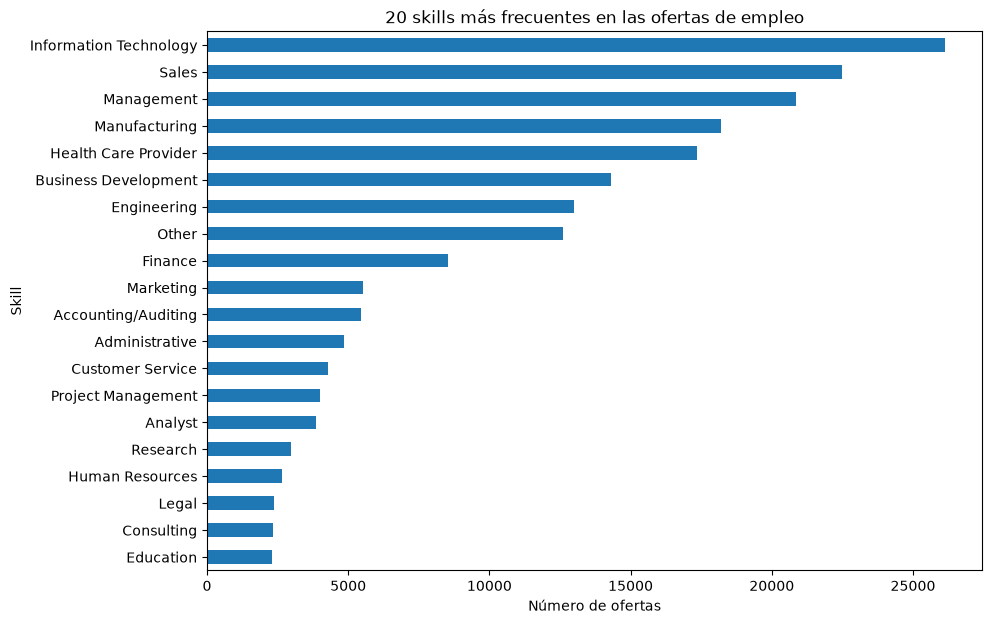

In [142]:
#representacion grafica de las habilidades mas asociadas a ofertas incluyendo el nombre
top_skills = (
    skills_frecuencia["skill_name"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10, 7))
top_skills.sort_values().plot(kind="barh")
plt.title("20 skills más frecuentes en las ofertas de empleo")
plt.xlabel("Número de ofertas")
plt.ylabel("Skill")
plt.show()

Podemos decir que Information Technology es la habilidad/categoría con mayor frecuencia, seguida de Sales y Management. También tienen una presencia importante Manufacturing, Health Care Provider, Business Development y Engineering.

Esto muestra que las ofertas analizadas están asociadas a una gran variedad de áreas profesionales, aunque existe una mayor concentración en ámbitos tecnológicos, comerciales, de gestión, manufactura y salud.

In [143]:
#num medio de skills por oferta de empleo
skills_por_oferta = job_skills.groupby("job_id").size()

skills_por_oferta.describe()

count    126807.000000
mean          1.685774
std           0.675907
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           3.000000
dtype: float64

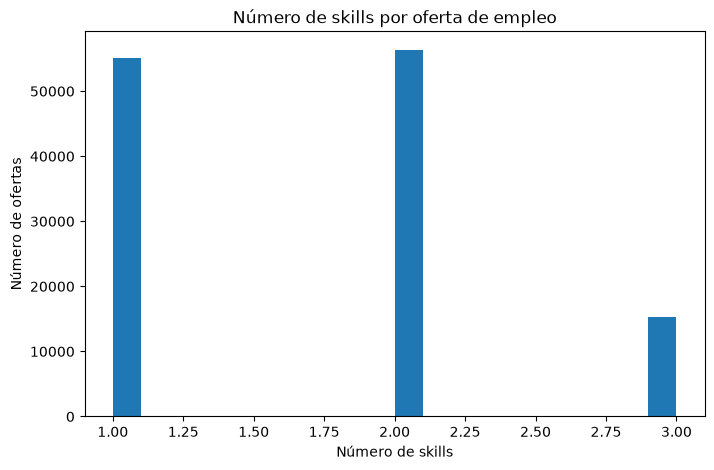

In [144]:
plt.figure(figsize=(8, 5))
plt.hist(skills_por_oferta, bins=20)
plt.title("Número de skills por oferta de empleo")
plt.xlabel("Número de skills")
plt.ylabel("Número de ofertas")
plt.show()

El análisis del número de habilidades asociadas a cada oferta muestra que se dispone de 126.807 ofertas con al menos una skill identificada. El número medio de skills por oferta es de 1,69, mientras que la mediana se sitúa en 2. El 75 % de las ofertas presenta como máximo 2 skills asociadas, y el máximo observado es de 3.

Estos resultados indican que, en general, las ofertas están asociadas a una o dos áreas de habilidades, aunque también existen algunas ofertas que presentan tres categorías de skills.

### 6.3 Industrias

In [145]:
#union tablas
industrias_frecuencia = (
    job_industries
    .merge(industries, on="industry_id", how="left")
)

industrias_frecuencia.head()

,job_id,industry_id,industry_name
0,3884428798,82,Book and Periodical Publishing
1,3887473071,48,Construction
2,3887465684,41,Banking
3,3887467939,82,Book and Periodical Publishing
4,3887467939,80,Advertising Services


In [146]:
#industrias mas frecuentes
top_industrias = (
    industrias_frecuencia["industry_name"]
    .value_counts()
    .head(20)
)

top_industrias

industry_name
Hospitals and Health Care             18326
Retail                                11033
IT Services and IT Consulting         10396
Staffing and Recruiting                9005
Financial Services                     8535
Software Development                   5091
Manufacturing                          3689
Construction                           3445
Banking                                2923
Insurance                              2673
Pharmaceutical Manufacturing           2469
Hospitality                            2455
Telecommunications                     2433
Real Estate                            2326
Industrial Machinery Manufacturing     2143
Non-profit Organizations               2063
Biotechnology Research                 2005
Accounting                             1968
Motor Vehicle Manufacturing            1951
Food and Beverage Services             1880
Name: count, dtype: int64

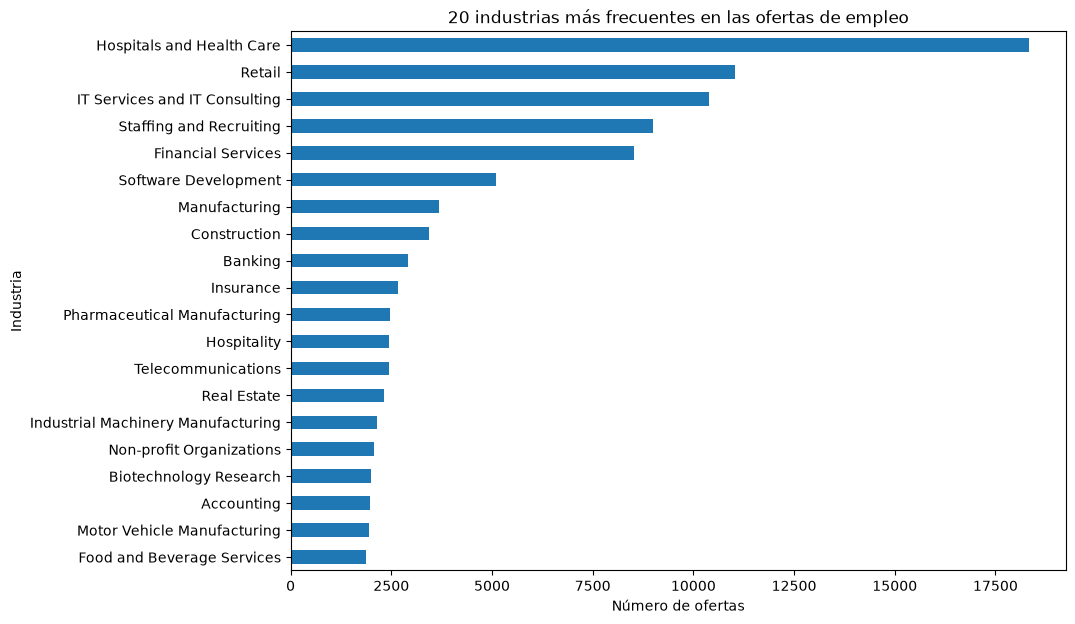

In [147]:
#reprentacion visual industrias mas frecuentes
plt.figure(figsize=(10, 7))

top_industrias.sort_values().plot(kind="barh")

plt.title("20 industrias más frecuentes en las ofertas de empleo")
plt.xlabel("Número de ofertas")
plt.ylabel("Industria")

plt.show()

Se observa que Hospitals and Health Care destaca claramente sobre el resto, con 18.326 asociaciones. También tienen una presencia importante los sectores de Retail, IT Services and IT Consulting, Staffing and Recruiting y Financial Services.

### 6.4 Beneficios

In [148]:
#beneficios mas frecuentes
beneficios_frecuencia = benefits["type"].value_counts()

beneficios_frecuencia

type
401(k)                     24231
Medical insurance           9873
Vision insurance            9309
Disability insurance        7930
Dental insurance            6868
Tuition assistance          2614
Commuter benefits           2226
Paid maternity leave        1808
Paid paternity leave        1540
Pension plan                 906
Student loan assistance      365
Child care support           273
Name: count, dtype: int64

In [149]:
#beneficios mas frecuentes
top_beneficios = beneficios_frecuencia.head(20)

top_beneficios

type
401(k)                     24231
Medical insurance           9873
Vision insurance            9309
Disability insurance        7930
Dental insurance            6868
Tuition assistance          2614
Commuter benefits           2226
Paid maternity leave        1808
Paid paternity leave        1540
Pension plan                 906
Student loan assistance      365
Child care support           273
Name: count, dtype: int64

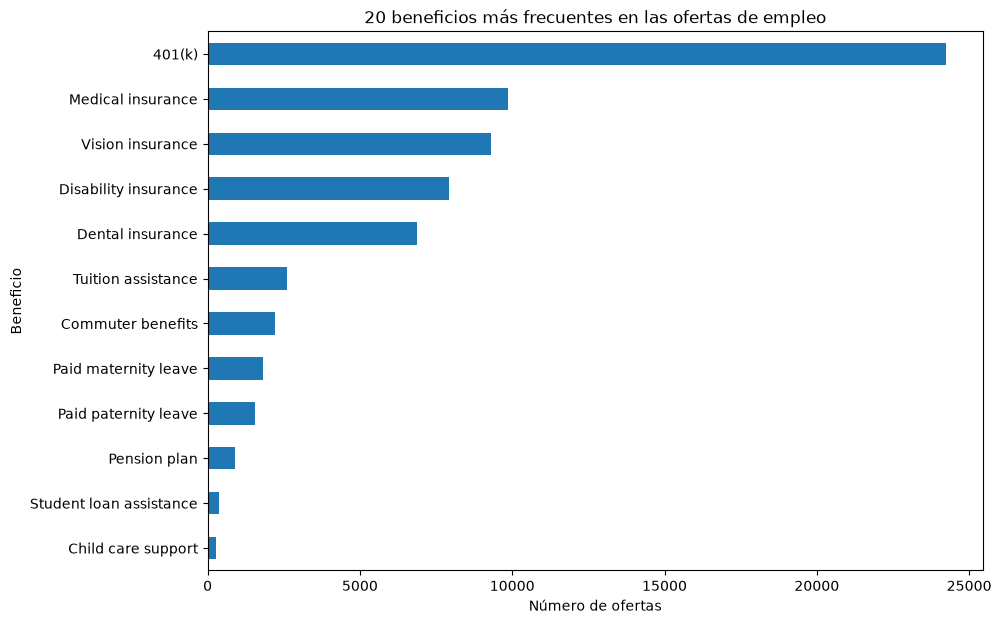

In [150]:
#representacion grafica beneficios mas frecuentes
plt.figure(figsize=(10, 7))

top_beneficios.sort_values().plot(kind="barh")

plt.title("20 beneficios más frecuentes en las ofertas de empleo")
plt.xlabel("Número de ofertas")
plt.ylabel("Beneficio")

plt.show()

El beneficio más frecuente es el 401(k) relacionado con una cuenta de ahorro para la jubilación en EEUU presente en 24.231 ofertas. A continuación, destacan los seguros, especialmente Medical insurance (9.873), Vision insurance (9.309), Disability insurance (7.930) y Dental insurance (6.868).

En general, se observa un claro predominio de los beneficios relacionados con la jubilación y los seguros.

### 7. RESUMEN

1. Datos utilizados

El proyecto trabaja principalmente con información de ofertas de empleo de LinkedIn y varias tablas relacionadas:

postings → ofertas de empleo.
companies → información de las empresas.
salaries → información salarial.
employee_counts → empleados y seguidores de las empresas.
job_skills + skills → habilidades asociadas a las ofertas.
job_industries + industries → industrias asociadas.
benefits → beneficios ofrecidos.
Tamaño principal
postings: 123.849 ofertas
employee_counts: 35.787 registros
salaries: 40.785 registros
job_skills: 213.768 asociaciones
skills: 35 categorías
benefits: 67.943 registros

2. Exploración inicial de los datos

Tipos de variables

Numéricas → salarios, empleados, seguidores, visualizaciones, solicitudes...
Categóricas → tipo de trabajo, experiencia, moneda, ubicación...
Texto → title, description, skills_desc.
Valores nulos

No se encontraron duplicados relevantes, por lo que no fue necesario eliminar registros duplicados.

3. Limpieza de datos
3.1 Corrección de tipos

Se corrigieron variables para que tuvieran el tipo adecuado:

Fechas/timestamps → datetime
company_id → entero nullable
zip_code → string
fips → string
benefits.inferred → boolean

4. Tratamiento de valores nulos

Se tomaron decisiones diferentes dependiendo de la variable.

postings
formatted_experience_level → los nulos se transformaron en Unknown.
description → había muy pocos nulos y se sustituyeron por Sin descripción.
Variables con gran cantidad de nulos → se mantienen como NaN cuando no existe información suficiente para imputarlas.
salaries

Los valores salariales ausentes no se imputaron, porque no existe información suficiente para determinar cuál debería ser el salario.

companies

La descripción tenía pocos nulos y se sustituyeron por: sin descripción

5. Normalización de categorías

Había muchas formas diferentes de representar el mismo estado:

Se unificaron las categorías utilizando las abreviaturas oficiales de los estados.

También se trataron valores claramente incorrectos, como 0, transformándolos en NaN.


6. Mercado estadounidense 🇺🇸

Se creó:

postings_eeuu = postings[postings["region"] == "EEUU"].copy()

La distribución era:

Región	Ofertas
EEUU	116.791
Otros	7.057
Europa	1

Por tanto:

94,30 % de las ofertas → EEUU
5,70 % → resto de regiones

Al centrarnos en EEUU se excluyen:

7.058 ofertas.

Esto permite realizar el análisis posterior centrado en el mercado laboral estadounidense, que es claramente el mercado predominante en el dataset.

7. Tratamiento del texto

Las principales variables de texto son:

title
description
skills_desc
title

Los títulos son generalmente cortos.

Media → 31,51 caracteres
Mediana → 28 caracteres

Los términos más frecuentes incluyen:

manager
engineer
sales
senior
assistant
specialist
associate
technician
nurse
analyst

8. description

Las palabras más frecuentes incluyen:

experience
team
ability
customer
support
management
skills
years
sales
required
care
service
health
data
development
Interpretación

Las ofertas hacen especial referencia a:

experiencia profesional,
habilidades y competencias,
trabajo en equipo,
atención al cliente,
gestión,
ventas,
salud,
datos y desarrollo.

9. skills_desc

Solo tiene información en aproximadamente el 2 % de las ofertas, mientras que alrededor del 98 % son valores ausentes.

skills_desc no resulta adecuada para realizar un análisis representativo de todas las ofertas debido a su elevada cantidad de valores ausentes.


10. Análisis de outliers

Se utilizó el método IQR 

Se detectaron valores extremos en:

views
applies
employee_count
follower_count
variables salariales.
Decisión importante

No se eliminaron automáticamente los outliers.

Se consideró que muchos valores extremos podían representar situaciones reales.Por tanto, se decidió mantener los valores originales y tenerlos en cuenta en la interpretación.


12. Variables categóricas

Se analizaron principalmente:

formatted_work_type
work_type
formatted_experience_level
application_type
pay_period
currency
compensation_type
location

Se comprobó que, en general, las categorías estaban correctamente normalizadas y eran coherentes.

Destaca que:

currency presenta un claro predominio del USD.
compensation_type presenta prácticamente una única categoría: BASE_SALARY.
location tiene una enorme diversidad de ubicaciones.

13. Skills 

Las más frecuentes fueron:

Information Technology → 26.137
Sales → 22.475
Management → 20.861
Manufacturing → 18.185
Health Care Provider → 17.369
Business Development → 14.290
Engineering → 13.009
Skills por oferta
Ofertas con al menos una skill → 126.807
Media → 1,69 skills
Mediana → 2
Máximo → 3
Conclusión

14. Industrias

Las industrias con mayor número de asociaciones fueron:

Hospitals and Health Care → 18.326
Retail → 11.033
IT Services and IT Consulting → 10.396
Staffing and Recruiting → 9.005
Financial Services → 8.535
Software Development → 5.091
Manufacturing → 3.689
Construction → 3.445
Banking → 2.923
Insurance → 2.673
Conclusión

15. Beneficios

Los más frecuentes fueron:

401(k) → 24.231
Medical insurance → 9.873
Vision insurance → 9.309
Disability insurance → 7.930
Dental insurance → 6.868
Tuition assistance → 2.614
Commuter benefits → 2.226
Paid maternity leave → 1.808
Paid paternity leave → 1.540
Pension plan → 906
Conclusión

Predominan claramente los beneficios relacionados con jubilacion y seguros


### 8. CORRELACIÓN

In [151]:
# Correlación entre salario y otras variables numéricas
postings_eeuu[["normalized_salary", "views", "applies"]].corr()

,normalized_salary,views,applies
normalized_salary,1.000000,-0.001557,-0.002310
views,-0.001557,1.000000,0.480427
applies,-0.002310,0.480427,1.000000


el salario no tiene ninguna relación con las visualizaciones (-0,0016) ni con el número de solicitudes (-0,0023), básicamente cero, es decir, que una oferta tenga un salario más alto o más bajo no hace que la gente la vea más o la solicite más. Lo único que sí se relaciona es views con applies (0,48): cuantas más veces se ve una oferta, más solicitudes recibe

In [152]:
# Salario medio según nivel de experiencia
postings_eeuu.groupby("formatted_experience_level")["normalized_salary"].mean().sort_values()

formatted_experience_level
Associate           8.077309e+04
Director            1.681859e+05
Unknown             1.731935e+05
Executive           1.988316e+05
Mid-Senior level    2.329229e+05
Entry level         2.618886e+05
Internship          1.002874e+06
Name: normalized_salary, dtype: float64

Estos números no tienen sentido tal cual porque un internship (prácticas) no puede tener de media más de un millón de dólares, y que "Entry level" salga por encima de "Mid-Senior level" tampoco cuadra. Esto es justo lo que ya detectó el propio notebook en el punto de outliers: hay valores salariales extremos, y como decidimos no eliminarlos, están "tirando" de la media hacia arriba  sobre todo en grupos pequeños como Internship, donde un solo valor disparatado puede desviar toda la media.

La solución es usar la mediana en vez de la media, que no se deja engañar tanto por esos valores extremos

In [153]:
# Salario mediano según nivel de experiencia (más robusto frente a outliers)
postings_eeuu.groupby("formatted_experience_level")["normalized_salary"].agg(["median", "count"]).sort_values("median")

,median,count
formatted_experience_level,,
Internship,48880.0,361
Entry level,52000.0,8427
Associate,72500.0,3439
Unknown,77500.0,7115
Mid-Senior level,105952.5,11442
Director,165000.0,1118
Executive,190000.0,334


Al usar la media, el salario por nivel de experiencia no tenía sentido (Internship salía con más de 1M$ de media) debido a los outliers salariales que decidimos no eliminar. Usando la mediana, que es más robusta frente a valores extremos, el salario sube de forma coherente según la seniority: de 48.880$ en Internship hasta 190.000$ en Executive.

### 9. Cruce salario con índice coste vida por estado EEUU

In [154]:
# Extraer el estado (las 2 letras después de la coma) desde location
postings_eeuu["estado"] = postings_eeuu["location"].str.split(",").str[-1].str.strip()

# Cargar el coste de vida por estado (fuente externa)
coste_vida = pd.read_csv(DATA_PATH / "coste_vida_por_estado.csv")
coste_vida = coste_vida.rename(columns={"state": "estado"})

# Cruzar (merge) con el coste de vida
postings_eeuu = postings_eeuu.merge(coste_vida, on="estado", how="left")

# Comprobar cuántas filas se han podido cruzar
print("Filas con coste de vida asignado:", postings_eeuu["indice_coste_vida"].notna().sum())
print("Filas sin coste de vida asignado:", postings_eeuu["indice_coste_vida"].isna().sum())


Filas con coste de vida asignado: 94353
Filas sin coste de vida asignado: 15642


In [155]:
postings_eeuu[["normalized_salary", "indice_coste_vida"]].corr()

,normalized_salary,indice_coste_vida
normalized_salary,1.000000,0.001661
indice_coste_vida,0.001661,1.000000


Se ha incorporado el índice de coste de vida por estado (Cost of Living Index, World Population Review / MERIC, 2026), cruzado a partir del estado extraído de la columna location (85,8% de las ofertas con estado identificable). La correlación con el salario normalizado es prácticamente nula (r = 0,0017), lo que indica que en este dataset el salario ofertado no varía de forma clara según el coste de vida del estado — probablemente porque la industria y el nivel de experiencia pesan más que la localización geográfica.

### 10. Extracción de skills desde el texto (NLP)

In [156]:
import re

skills_list = ["Python", "SQL", "R", "Excel", "Power BI", "Tableau", "AWS", "Azure", "GCP",
               "Spark", "Hadoop", "Machine Learning", "Deep Learning", "TensorFlow", "PyTorch",
               "NLP", "Scikit-learn", "Pandas", "Git", "Docker", "Kubernetes", "Java", "Scala",
               "Airflow", "ETL", "Statistics", "Linux", "API", "Snowflake", "MongoDB"]

def buscar_skills(texto, skills_list):
    if pd.isna(texto):
        return {skill: 0 for skill in skills_list}
    texto_lower = texto.lower()
    resultado = {}
    for skill in skills_list:
        patron = r'\b' + re.escape(skill.lower()) + r'\b'
        resultado[skill] = int(bool(re.search(patron, texto_lower)))
    return resultado

In [157]:
# Aplicar la búsqueda de skills a cada oferta
skills_encontradas = postings_eeuu["description"].apply(lambda x: buscar_skills(x, skills_list))

# Convertir el resultado en una tabla (una columna por skill)
skills_df = pd.DataFrame(list(skills_encontradas))

# Añadir el job_id para identificar cada oferta
skills_df.insert(0, "job_id", postings_eeuu["job_id"].values)

# Ver las primeras filas
skills_df.head()

,job_id,Python,SQL,R,Excel,Power BI,Tableau,AWS,Azure,GCP,...,Kubernetes,Java,Scala,Airflow,ETL,Statistics,Linux,API,Snowflake,MongoDB
0,921716,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10998357,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,23221523,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,91700727,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,103254301,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [158]:
skills_df.drop(columns="job_id").sum().sort_values(ascending=False)

Excel               16232
SQL                  4624
R                    4323
Python               4022
AWS                  2783
Azure                2567
Java                 2332
Statistics           1769
API                  1664
Linux                1491
Machine Learning     1490
Tableau              1120
Git                  1016
Kubernetes           1016
Power BI              923
Docker                911
GCP                   866
ETL                   774
Spark                 727
Snowflake             468
Scala                 340
MongoDB               264
Hadoop                258
Deep Learning         247
PyTorch               193
TensorFlow            173
NLP                   169
Airflow               153
Scikit-learn           73
Pandas                 70
dtype: int64

In [159]:
import re

ejemplos_sql = postings_eeuu.loc[skills_df["SQL"] == 1, "description"].sample(5, random_state=1)
for texto in ejemplos_sql:
    match = re.search(r'.{0,80}\bsql\b.{0,80}', texto, flags=re.IGNORECASE)
    if match:
        print("..." + match.group() + "...")
    else:
        print("(no encontrado, raro)")
    print("---")

...om scratch, participate in DR activitiesKnowledge of Application aware backups (SQL, Oracle, Exchange etc.)Knowledge of Avamar, Data Domain, CyberRecovery and Cybe...
---
...g knowledge of at least one of the following statistical software packages: SAS/SQL (required) SPSS, or equivalent; SAS Enterprise Miner experience is a plus....
---
...l modeling techniquesProficient in programming languages such as Python, R, and SQL for data manipulation and analysisExperience with big data technologies (e.g., ...
---
...ent in at least one programming language (Python, JavaScript, HTML, C++, C# and SQL) and able to solve coding problems (think LeetCode, HackerRank, etc). For each ...
---
... Strong experience in Axiom development and implementationProficiency in SQL, PL/SQL, and Oracle databaseKnowledge of data modeling and data warehousing con...
---


Método:
-Se definió una lista de 29 skills relevantes en datos e IA (Python, SQL, R, Excel, Power BI, AWS, Machine Learning, etc.).
-Se buscó cada skill en el texto de la oferta como palabra completa (usando expresiones regulares con límites de palabra), no como texto suelto, para evitar falsos positivos.
-Se validó el resultado revisando manualmente ejemplos reales de ofertas marcadas con la skill "SQL", confirmando que las coincidencias son correctas.

Resultado: la tabla `skills_df`, con una fila por oferta (`job_id`) y una columna por skill (1 si la menciona, 0 si no). Las skills más pedidas son Excel, SQL, R, Python y AWS.

### 11. Preparar la tabla para el modelo de salario

A partir de aquí se construye la tabla final que usará el modelo: se combinan skills, industria, región y coste de vida junto al salario de cada oferta (normalized_salary).

In [160]:
print(list(tablas.keys()))

['companies', 'company_industries', 'company_specialities', 'employee_counts', 'industries', 'postings', 'benefits', 'salaries', 'jobs_industries', 'jobs_skills', 'skills']


In [161]:
# Cogemos una industria por oferta (la primera, para simplificar)
job_industries = tablas["jobs_industries"].drop_duplicates(subset="job_id", keep="first")

# Traemos el nombre de la industria
industrias = tablas["industries"]
job_industria = job_industries.merge(industrias, on="industry_id", how="left")[["job_id", "industry_name"]]

# Unimos la industria a postings_eeuu
postings_eeuu = postings_eeuu.merge(job_industria, on="job_id", how="left")

print("Ofertas con industria asignada:", postings_eeuu["industry_name"].notna().sum())
print("Ofertas sin industria asignada:", postings_eeuu["industry_name"].isna().sum())

Ofertas con industria asignada: 109859
Ofertas sin industria asignada: 136


In [162]:
# Unimos las skills a postings_eeuu
postings_eeuu = postings_eeuu.merge(skills_df, on="job_id", how="left")

print("Filas antes de perder ninguna:", len(postings_eeuu))
print("Columnas ahora:", postings_eeuu.shape[1])

Filas antes de perder ninguna: 109995
Columnas ahora: 66


In [163]:
# Nos quedamos con las ofertas que tienen salario registrado normalized_salary

dataset_modelo = postings_eeuu[postings_eeuu["normalized_salary"].notna()].copy()

print("Ofertas con salario:", len(dataset_modelo))
print("Ofertas descartadas (sin salario):", len(postings_eeuu) - len(dataset_modelo))

Ofertas con salario: 32236
Ofertas descartadas (sin salario): 77759


Preparamos las variables que va a usar el modelo (las 29 skills, la industria convertida en columnas 0/1, y el índice de coste de vida como indicador de región) separadas del salario, que es lo que queremos predecir.

In [164]:

# Lista de columnas de skills (la misma que usamos para extraerlas)
columnas_skills = skills_list

# Convertimos la industria en columnas 0/1 (una por industria)
industria_dummies = pd.get_dummies(dataset_modelo["industry_name"], prefix="industria")

# Tabla de variables (X) y salario a predecir (y)
X = pd.concat([dataset_modelo[columnas_skills], dataset_modelo[["indice_coste_vida"]], industria_dummies], axis=1)
y = dataset_modelo["normalized_salary"]

print("Forma de X (filas, columnas):", X.shape)
print("Forma de y (filas):", y.shape)
print("Nulos en X:", X.isna().sum().sum())

Forma de X (filas, columnas): (32236, 363)
Forma de y (filas): (32236,)
Nulos en X: 5308


Esos 5.308 nulos vienen del índice de coste de vida (las ofertas cuya location no tenía un formato reconocible). Los quitamos y dejamos X e y alineados y listos para entrenar.

In [165]:
X = X.dropna()
y = y.loc[X.index]

print("Filas finales para entrenar:", len(X))

Filas finales para entrenar: 26928


Con esto queda lista la tabla final para el modelo: por cada oferta con salario conocido, tenemos sus skills (0/1), su industria (codificada) y el índice de coste de vida como indicador de región. 26.928 ofertas listas para entrenar.

In [166]:
# Quitamos salarios inválidos (0$) y outliers extremos (>500.000$)
antes = len(X)
mask = (y > 0) & (y <= 500000)
X = X[mask]
y = y[mask]

print("Filas antes:", antes)
print("Filas después de quitar outliers:", len(X))

Filas antes: 26928
Filas después de quitar outliers: 26863


### 12. Entrenar el modelo de salario (Random Forest)

Se divide la tabla en entrenamiento (80%) y prueba (20%), y se entrena un modelo Random Forest para predecir el salario a partir de skills, industria y región.

In [167]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamos el modelo
modelo = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo.fit(X_train, y_train)

print("Modelo entrenado con", len(X_train), "ofertas")

Modelo entrenado con 21490 ofertas


Usamos el modelo para predecir el salario de las ofertas de prueba (las que no ha visto durante el entrenamiento) y lo comparamos con el salario real, para ver si acierta

In [168]:
from sklearn.metrics import mean_absolute_error, r2_score

# Predecimos sobre los datos de prueba
y_pred = modelo.predict(X_test)

# Comparamos con el salario real
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Error medio (MAE):", round(mae, 2), "dólares")
print("R² (0 a 1, cuanto más cerca de 1, mejor):", round(r2, 3))

Error medio (MAE): 34691.49 dólares
R² (0 a 1, cuanto más cerca de 1, mejor): 0.191


Interpretación de las métricas:

-MAE (Error Absoluto Medio) = 34.691,49$: de media, el modelo se equivoca en unos 34.700$ (arriba o abajo) al predecir el salario de una oferta.
-R² = 0,191: las variables usadas (skills, industria y coste de vida por estado) explican cerca del 19% de la variación del salario entre ofertas. El 81% restante depende de otros factores no incluidos en el modelo, principalmente el nivel de experiencia, que en el análisis exploratorio ya mostró tener una relación mucho más fuerte con el salario que las skills individuales.

Confirma que el nivel de experiencia pesa más que las skills concretas a la hora de determinar el salario.

In [169]:
# Importancia de cada variable individual
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
print("TOP 15 variables más importantes:")
print(importancias.head(15))

# Importancia agrupada por tipo de variable (skills / industria / región)
grupo = pd.Series(index=X.columns, dtype="object")
grupo[X.columns.isin(skills_list)] = "Skills"
grupo[X.columns.str.startswith("industria_")] = "Industria"
grupo["indice_coste_vida"] = "Región (coste de vida)"

importancia_por_grupo = importancias.groupby(grupo).sum().sort_values(ascending=False)
print("\nImportancia total por tipo de variable:")
print(importancia_por_grupo)

TOP 15 variables más importantes:
indice_coste_vida                          0.287373
industria_Retail                           0.054934
Excel                                      0.051808
industria_Software Development             0.042158
Machine Learning                           0.040051
Python                                     0.036576
AWS                                        0.025367
R                                          0.022001
Java                                       0.019338
SQL                                        0.014025
Statistics                                 0.011849
industria_IT Services and IT Consulting    0.011773
Azure                                      0.010980
industria_Financial Services               0.010244
industria_Hospitality                      0.009797
dtype: float64

Importancia total por tipo de variable:
Industria                 0.415933
Skills                    0.296694
Región (coste de vida)    0.287373
dtype: float64


Importancia de las variables: el índice de coste de vida (una sola variable) es, por sí solo, el predictor individual más importante del modelo (28,7%), por encima de cualquier skill o industria concreta. Agrupando por tipo, la industria pesa algo más en conjunto (41,6%) que las skills (29,7%) y la región (28,7%) — aunque hay que tener en cuenta que la industria y las skills se reparten entre ~140 y 29 columnas respectivamente, mientras que la región es una única variable. Esto confirma que el cruce con la fuente externa (coste de vida por estado) aporta información relevante y justifica esa decisión tomada al principio del proyecto.

In [170]:
def predecir_salario(skills_seleccionadas, industria, indice_coste_vida_valor):
    # Fila vacía con todas las columnas que espera el modelo, a 0
    fila = pd.Series(0, index=X.columns, dtype=float)

    # Marcamos las skills seleccionadas
    for skill in skills_seleccionadas:
        if skill in fila.index:
            fila[skill] = 1

    # Marcamos la industria
    columna_industria = f"industria_{industria}"
    if columna_industria in fila.index:
        fila[columna_industria] = 1

    # Coste de vida de la zona
    fila["indice_coste_vida"] = indice_coste_vida_valor

    # Predicción
    salario_estimado = modelo.predict(pd.DataFrame([fila]))[0]
    return round(salario_estimado, 2)

# Ejemplo de uso
ejemplo = predecir_salario(["Python", "SQL", "Machine Learning"], "Software Development", 142.3)
print("Salario estimado:", ejemplo, "$")

Salario estimado: 148082.6 $


In [171]:
postings_eeuu[["job_id", "formatted_experience_level", "normalized_salary"]].to_csv("dataset/salarios_experiencia.csv", index=False)

In [172]:
import joblib

joblib.dump(modelo, "modelo_salario.pkl")
print("Modelo guardado")

Modelo guardado


In [173]:
joblib.dump(list(X.columns), "columnas_modelo.pkl")
print("Columnas guardadas:", len(X.columns))

Columnas guardadas: 363
